<a href="https://colab.research.google.com/github/jmoralespineda/TEORIA_DE_SE-ALES/blob/main/Estimaci%C3%B3n_PSD_y_Autocorrelaci%C3%B3n_Base_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Taller en clase**

#**Base de datos: wheather_feature - variable de interes: wind_speed**
#Julian David Morales Pineda

#importe de la base de datos

In [ ]:
import pandas as pd

# Replace 'your_database.csv' with the actual path to your database file
try:
    df = pd.read_csv('wheather_feature-humidity.txt')
    print("Database loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("Error: The file 'wheather_feature-humidity.txt' was not found. Please provide the correct path to your database file.")
except Exception as e:
    print(f"An error occurred: {e}")

Database loaded successfully!


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


#separamos la variable de interes

In [ ]:
wind_speed_data = df['wind_speed']
display(wind_speed_data.head())

,wind_speed
0,1
1,1
2,0
3,0
4,0


#Señal en el tiempo

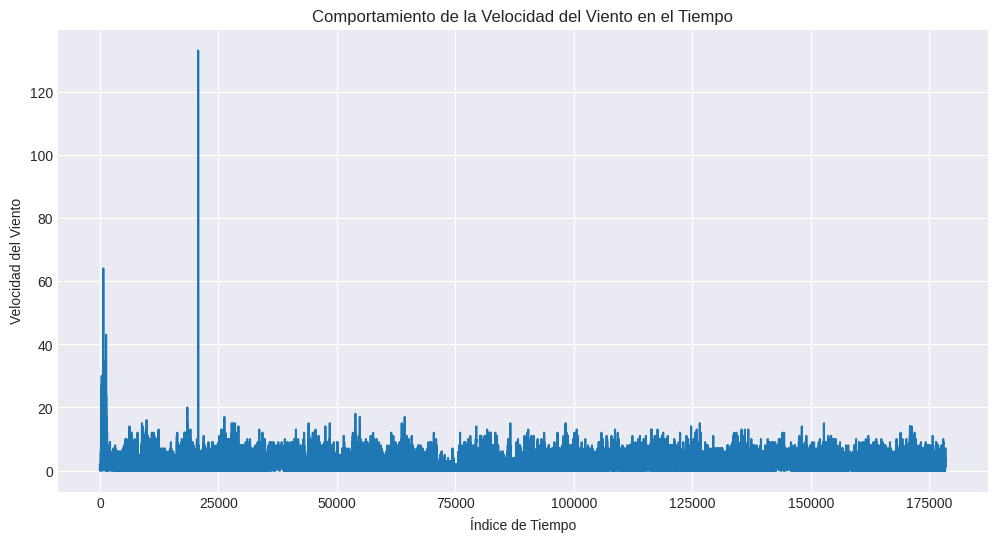

In [ ]:
import matplotlib.pyplot as plt

# Take the variable of interest (wind_speed_data)
# This variable already holds the 'wind_speed' column extracted earlier
wind_speed_time_series = wind_speed_data

# Create a figure and an axes for the plot
plt.figure(figsize=(12, 6)) # Set the size of the plot

# Plot the time series data
# We are plotting the wind_speed values against their index (representing time)
plt.plot(wind_speed_time_series)

# Add a title to the plot
plt.title('Comportamiento de la Velocidad del Viento en el Tiempo')

# Add labels to the x and y axes
plt.xlabel('Índice de Tiempo')
plt.ylabel('Velocidad del Viento')

# Add a grid to the plot for better readability
plt.grid(True)

# Display the plot
plt.show()

# Funcion de autocorrelacion.

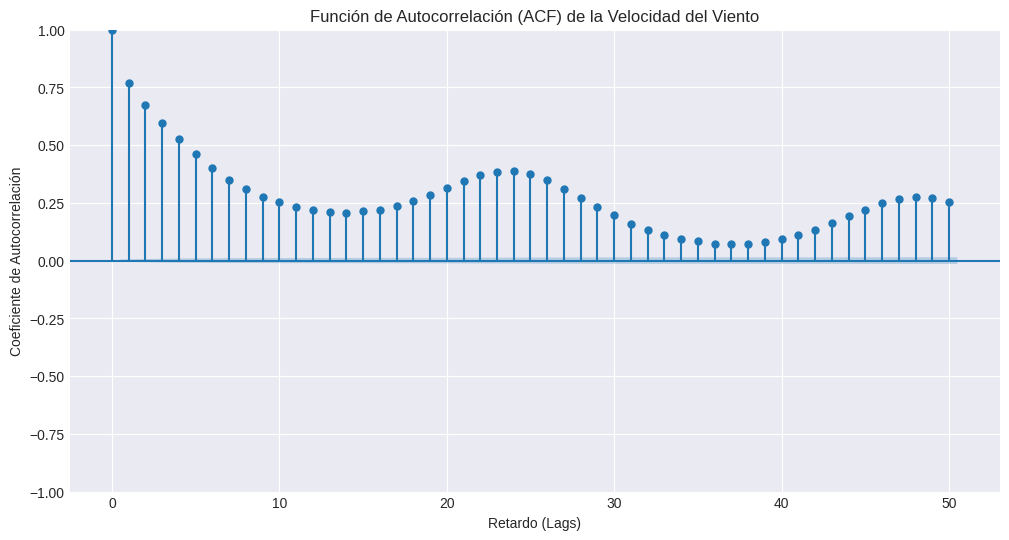

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Calculate and plot the Autocorrelation Function (ACF)
# The ACF measures how a time series is correlated with a lagged version of itself.
# Lags represent the time intervals between the observations.
plt.figure(figsize=(12, 6)) # Set the size of the plot
plot_acf(wind_speed_data, lags=50, ax=plt.gca()) # Calculate and plot ACF with up to 50 lags

# Add a title to the plot
plt.title('Función de Autocorrelación (ACF) de la Velocidad del Viento')

# Add labels to the x and y axes
plt.xlabel('Retardo (Lags)')
plt.ylabel('Coeficiente de Autocorrelación')

# Add a grid to the plot for better readability
plt.grid(True)

# Display the plot
plt.show()

#Analisis Espectral

🔧 Dispositivo seleccionado: cpu
✓ Usando CPU

INICIANDO ANÁLISIS DE PSD PARA: SEÑAL_DE_PRUEBA
🚀 Usando aceleración con: cpu
📅 Fecha y Hora: 2025-10-01 14:56:09
FASE 1: PREPROCESAMIENTO CON PYTORCH
✓ Puntos de datos originales: 1000
✓ Puntos de datos válidos (sin NaN): 1000

Estadísticas (calculadas con PyTorch):
  Media: 0.0071
  Desviación estándar: 0.9505
  Mínimo: -2.6870
  Máximo: 2.5180
✓ Tendencia lineal removida (pendiente calculada: -0.000030)

FASE 2: DENSIDAD ESPECTRAL DE POTENCIA (PSD) CON MÉTODO DE WELCH
✓ PSD calculada en cpu usando el método de Welch.
✓ Tamaño de la ventana: 512
✓ Solapamiento entre ventanas: 384 puntos (75.0%)
✓ Resolución frecuencial: 0.195312 Hz
✓ Potencia total (integral de la PSD): 0.9095

FASE 3: ANÁLISIS TIEMPO-FRECUENCIA (ESPECTROGRAMA STFT)
✓ Espectrograma STFT calculado.
✓ Tamaño de ventana FFT: 128
✓ Desplazamiento (Hop length): 32
✓ Forma de la matriz del espectrograma: torch.Size([65, 32])
✓ Rango temporal cubierto: 0 a 9.92 unidades de tiemp

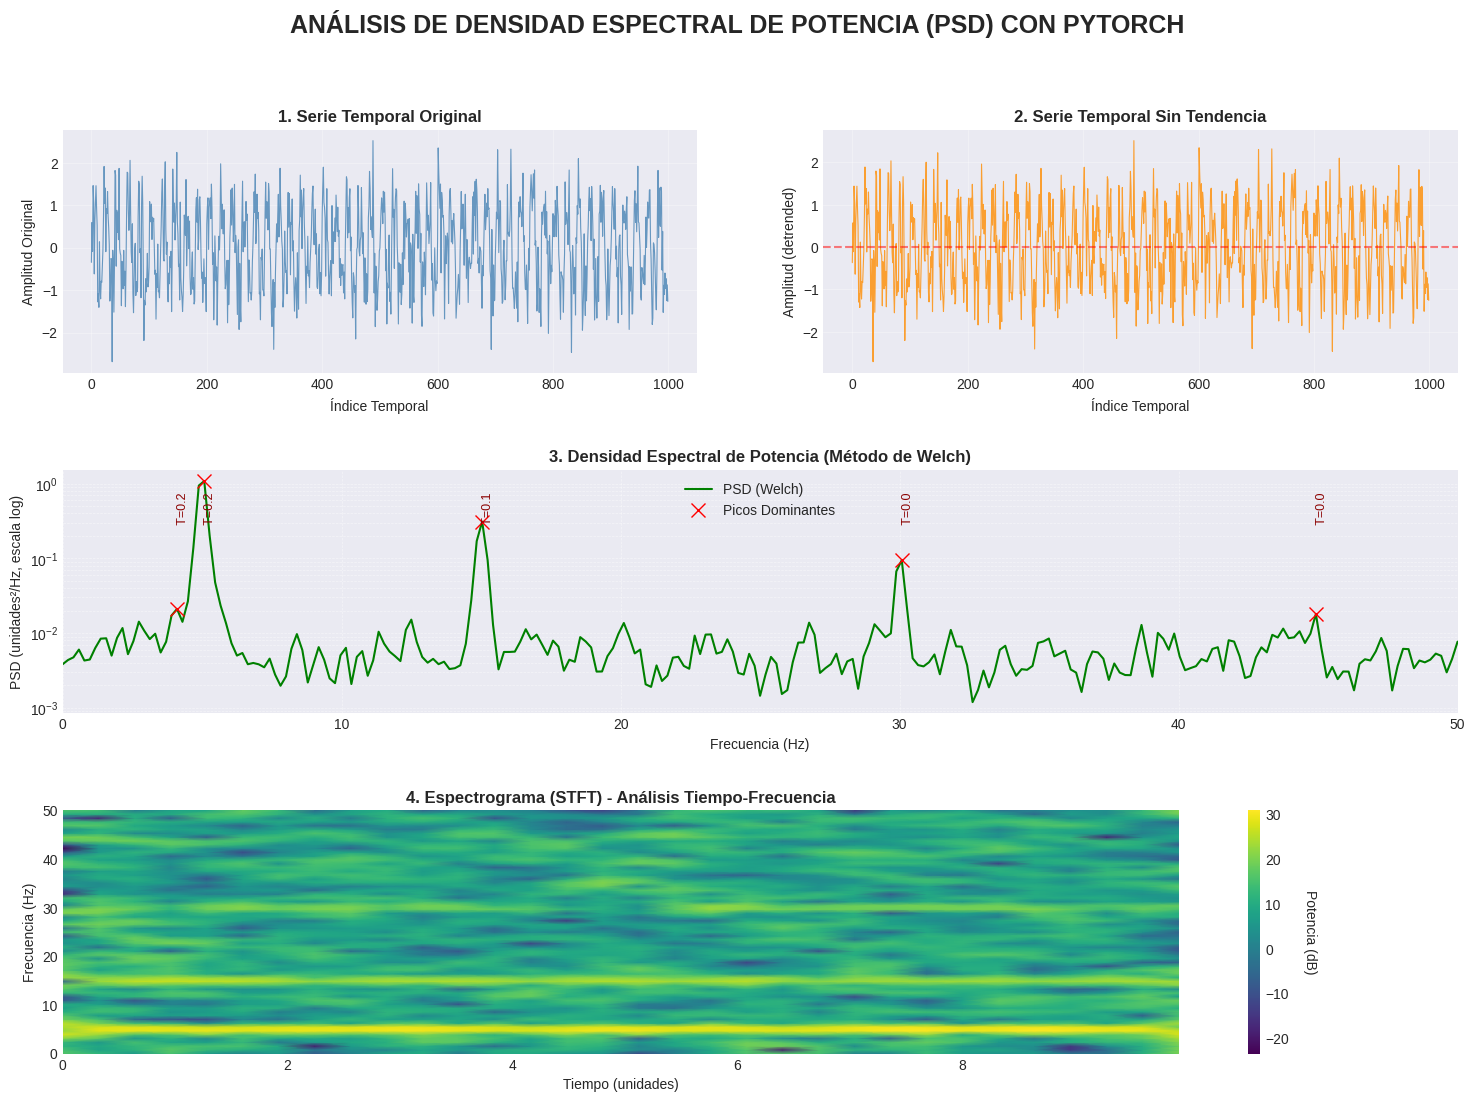

✓ Visualizaciones generadas exitosamente

✅ ANÁLISIS ESPECTRAL BASADO EN PSD COMPLETADO EXITOSAMENTE

📊 RESUMEN FINAL: FRECUENCIAS DOMINANTES IDENTIFICADAS


,Rango,Frecuencia (Hz),Periodo (unidades),PSD (unidades²/Hz)
0,1,5.078125,0.196923,1.086231
1,2,15.039062,0.066494,0.312040
2,3,30.078125,0.033247,0.094810
3,4,4.101562,0.243810,0.021093
4,5,44.921875,0.022261,0.018060
5,6,12.500000,0.080000,0.015146
6,7,2.734375,0.365714,0.014228
7,8,26.757812,0.037372,0.013802
8,9,20.117188,0.049709,0.013658
9,10,29.101562,0.034362,0.013145


In [47]:
"""
================================================================================
ANÁLISIS DE DENSIDAD ESPECTRAL DE POTENCIA (PSD) CON PYTORCH
================================================================================
Enfoque principal: Método de Welch para una estimación espectral robusta.
"""

# =============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =============================================================================
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# Configuración de PyTorch para seleccionar el dispositivo (GPU o CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Dispositivo seleccionado: {device}")
# Imprime el nombre de la GPU si está disponible, de lo contrario, indica que se usa la CPU
if torch.cuda.is_available():
    print(f"✓ GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    print("✓ Usando CPU")

# Configuración de los estilos y tamaños para las visualizaciones de Matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10

# =============================================================================
# 2. PREPROCESAMIENTO CON PYTORCH
# =============================================================================

def preprocesar_datos_torch(serie_temporal):
    """
    Preprocesa la serie temporal usando operaciones de PyTorch.

    Parámetros:
    -----------
    serie_temporal : pandas.Series
        Serie temporal de entrada que se va a procesar.

    Retorna:
    --------
    datos_detrended : torch.Tensor
        Tensor sin la tendencia lineal principal.
    datos_tensor : torch.Tensor
        Tensor original convertido a PyTorch.
    estadisticas : dict
        Diccionario que contiene las estadísticas básicas de la señal.
    """
    print("=" * 80)
    print("FASE 1: PREPROCESAMIENTO CON PYTORCH")
    print("=" * 80)

    # Elimina los valores NaN de la serie y la convierte a un array de numpy
    datos_validos = serie_temporal.dropna().values
    print(f"✓ Puntos de datos originales: {len(serie_temporal)}")
    print(f"✓ Puntos de datos válidos (sin NaN): {len(datos_validos)}")

    # Convierte el array de numpy a un tensor de PyTorch con tipo float32 y lo mueve al dispositivo seleccionado
    datos_tensor = torch.tensor(datos_validos, dtype=torch.float32, device=device)

    # Calcula estadísticas descriptivas básicas utilizando funciones de PyTorch
    media = torch.mean(datos_tensor)
    std = torch.std(datos_tensor)
    minimo = torch.min(datos_tensor)
    maximo = torch.max(datos_tensor)

    # Imprime las estadísticas calculadas
    print(f"\nEstadísticas (calculadas con PyTorch):")
    print(f"  Media: {media.item():.4f}")
    print(f"  Desviación estándar: {std.item():.4f}")
    print(f"  Mínimo: {minimo.item():.4f}")
    print(f"  Máximo: {maximo.item():.4f}")

    # Eliminación de la tendencia lineal (detrending)
    # Se crea un eje de tiempo (índices) para ajustar una regresión lineal
    n = len(datos_tensor)
    x = torch.arange(n, dtype=torch.float32, device=device)

    # Se calculan los parámetros de la regresión lineal (y = a*x + b) para modelar la tendencia
    x_mean = torch.mean(x)
    y_mean = torch.mean(datos_tensor)
    numerador = torch.sum((x - x_mean) * (datos_tensor - y_mean))
    denominador = torch.sum((x - x_mean) ** 2)
    pendiente = numerador / denominador
    intercepto = y_mean - pendiente * x_mean

    # Se construye la línea de tendencia y se resta de la señal original
    tendencia = pendiente * x + intercepto
    datos_detrended = datos_tensor - tendencia

    print(f"✓ Tendencia lineal removida (pendiente calculada: {pendiente.item():.6f})")

    # Almacena las estadísticas en un diccionario para su posterior uso
    estadisticas = {
        'media': media.item(),
        'std': std.item(),
        'min': minimo.item(),
        'max': maximo.item(),
        'n_puntos': n
    }

    # Devuelve la serie sin tendencia, la serie original como tensor y las estadísticas
    return datos_detrended, datos_tensor, estadisticas

# =============================================================================
# 3. DENSIDAD ESPECTRAL DE POTENCIA (PSD) CON MÉTODO DE WELCH USANDO PYTORCH
# =============================================================================

def calcular_psd_welch_torch(datos_tensor, frecuencia_muestreo=1.0, n_fft=256, hop_length=None):
    """
    Calcula la Densidad Espectral de Potencia (PSD) usando el método de Welch.
    Esta implementación utiliza la función STFT de PyTorch para obtener los espectros
    de segmentos superpuestos y luego los promedia.

    Parámetros:
    -----------
    datos_tensor : torch.Tensor
        Serie temporal en formato tensor (sin tendencia).
    frecuencia_muestreo : float
        Frecuencia a la que se muestreó la señal (en Hz).
    n_fft : int
        Tamaño de la ventana de análisis (y tamaño de la FFT).
    hop_length : int, opcional
        Desplazamiento entre ventanas consecutivas. Por defecto, n_fft // 4.

    Retorna:
    --------
    frecuencias_psd : torch.Tensor
        Eje de frecuencias para la PSD.
    psd : torch.Tensor
        Valores de la Densidad Espectral de Potencia.
    """
    print("\n" + "=" * 80)
    print("FASE 2: DENSIDAD ESPECTRAL DE POTENCIA (PSD) CON MÉTODO DE WELCH")
    print("=" * 80)

    # Si no se especifica hop_length, se usa un solapamiento del 75%
    if hop_length is None:
        hop_length = n_fft // 4

    # Se utiliza una ventana de Hann para reducir el "leakage" espectral
    window = torch.hann_window(n_fft, device=device)

    # Se calcula la STFT. La función torch.stft divide la señal en segmentos,
    # aplica la ventana y calcula la FFT para cada uno.
    stft_resultado = torch.stft(
        datos_tensor,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=n_fft,
        window=window,
        return_complex=True,
        center=True
    )

    # La PSD se estima como el valor esperado de la magnitud al cuadrado del espectro.
    # Aquí, aproximamos el valor esperado promediando sobre los segmentos de tiempo.
    # Primero, calculamos la magnitud al cuadrado de los coeficientes complejos de la STFT
    # El factor 2 es para incluir la potencia de las frecuencias negativas.
    psd_temporal = 2.0 * torch.abs(stft_resultado) ** 2

    # Luego, promediamos a lo largo del eje del tiempo (dim=1) para obtener la PSD final
    psd = torch.mean(psd_temporal, dim=1)

    # Se calcula el factor de normalización para que la PSD esté en unidades de V^2/Hz
    # Esto asegura que la integral de la PSD sea igual a la potencia total de la señal.
    # El denominador es la suma de los cuadrados de la ventana, dividido por el número de puntos.
    # Esto es equivalente a (1/fs) * E[|X(f)|^2]
    psd /= (frecuencia_muestreo * (window**2).sum())

    # Se genera el eje de frecuencias correspondiente, desde 0 hasta la frecuencia de Nyquist
    frecuencias_psd = torch.fft.rfftfreq(n_fft, d=1/frecuencia_muestreo).to(device)

    print(f"✓ PSD calculada en {device} usando el método de Welch.")
    print(f"✓ Tamaño de la ventana: {n_fft}")
    print(f"✓ Solapamiento entre ventanas: {n_fft - hop_length} puntos ({100 * (n_fft - hop_length) / n_fft:.1f}%)")
    print(f"✓ Resolución frecuencial: {(frecuencias_psd[1] - frecuencias_psd[0]).item():.6f} Hz")
    print(f"✓ Potencia total (integral de la PSD): {torch.sum(psd) * (frecuencias_psd[1] - frecuencias_psd[0]).item():.4f}")

    return frecuencias_psd, psd

# =============================================================================
# 4. SHORT-TIME FOURIER TRANSFORM (STFT) PARA ESPECTROGRAMA
# =============================================================================

def calcular_stft_torch(datos_tensor, frecuencia_muestreo=1.0, n_fft=256, hop_length=None):
    """
    Calcula la STFT para generar un espectrograma (análisis tiempo-frecuencia).

    Parámetros:
    -----------
    datos_tensor : torch.Tensor
        Serie temporal de entrada.
    frecuencia_muestreo : float
        Frecuencia de muestreo de la señal.
    n_fft : int
        Tamaño de la ventana de la FFT.
    hop_length : int
        Desplazamiento entre ventanas consecutivas.

    Retorna:
    --------
    stft_mag : torch.Tensor
        Magnitud del espectrograma.
    frecuencias_stft : torch.Tensor
        Eje de frecuencias del espectrograma.
    tiempos_stft : torch.Tensor
        Eje de tiempos del espectrograma.
    """
    print("\n" + "=" * 80)
    print("FASE 3: ANÁLISIS TIEMPO-FRECUENCIA (ESPECTROGRAMA STFT)")
    print("=" * 80)

    # Si no se define el hop_length, se utiliza un solapamiento del 75% por defecto
    if hop_length is None:
        hop_length = n_fft // 4

    # La función STFT de PyTorch requiere que la entrada tenga una dimensión de 'batch'
    # Por eso, se añade una dimensión al principio con unsqueeze(0).
    datos_reshaped = datos_tensor.unsqueeze(0)

    # Se calcula la STFT usando la ventana de Hann para reducir artefactos
    stft_resultado = torch.stft(
        datos_reshaped,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=n_fft,
        window=torch.hann_window(n_fft).to(device),
        return_complex=True,
        center=True
    )

    # Se calcula la magnitud del resultado complejo y se elimina la dimensión de 'batch'
    stft_mag = torch.abs(stft_resultado.squeeze(0))

    # Se generan los ejes de frecuencia y tiempo para el gráfico del espectrograma
    n_frames = stft_mag.shape[1]
    frecuencias_stft = torch.linspace(0, frecuencia_muestreo/2, n_fft//2 + 1).to(device)
    tiempos_stft = torch.arange(n_frames).to(device) * hop_length / frecuencia_muestreo

    print(f"✓ Espectrograma STFT calculado.")
    print(f"✓ Tamaño de ventana FFT: {n_fft}")
    print(f"✓ Desplazamiento (Hop length): {hop_length}")
    print(f"✓ Forma de la matriz del espectrograma: {stft_mag.shape}")
    print(f"✓ Rango temporal cubierto: 0 a {tiempos_stft[-1].item():.2f} unidades de tiempo")

    return stft_mag, frecuencias_stft, tiempos_stft

# =============================================================================
# 5. IDENTIFICACIÓN DE FRECUENCIAS DOMINANTES
# =============================================================================

def identificar_picos_torch(frecuencias, psd, n_picos=10, threshold=0.01):
    """
    Identifica las frecuencias dominantes (picos) en la PSD.

    Parámetros:
    -----------
    frecuencias : torch.Tensor
        Array de frecuencias correspondiente a la PSD.
    psd : torch.Tensor
        Array con los valores de la Densidad Espectral de Potencia.
    n_picos : int
        Número máximo de picos a identificar.
    threshold : float
        Umbral de altura relativo al pico máximo para considerar un pico.

    Retorna:
    --------
    df_picos : pandas.DataFrame
        DataFrame con la información detallada de los picos encontrados.
    """
    print("\n" + "=" * 80)
    print("FASE 4: IDENTIFICACIÓN DE FRECUENCIAS DOMINANTES")
    print("=" * 80)

    # Mueve los tensores a la CPU y los convierte a numpy para usar SciPy
    psd_cpu = psd.cpu().numpy()
    frecuencias_cpu = frecuencias.cpu().numpy()

    # Se utiliza la función find_peaks de SciPy, que es muy robusta para esta tarea
    # Se define un umbral de altura mínimo para filtrar picos de bajo ruido
    umbral = np.max(psd_cpu) * threshold
    picos, propiedades = signal.find_peaks(psd_cpu, height=umbral, distance=5)

    # Si se encontraron picos, se ordenan por su altura (potencia) de mayor a menor
    if len(picos) > 0:
        # Ordena los índices de los picos según su altura en orden descendente y selecciona los n_picos principales
        indices_ordenados = np.argsort(propiedades['peak_heights'])[::-1][:n_picos]
        picos_principales = picos[indices_ordenados]

        resultados = []
        # Calcula la potencia total como la integral de la PSD (aproximada por la suma de Riemann)
        potencia_total = np.sum(psd_cpu) * (frecuencias_cpu[1] - frecuencias_cpu[0])

        # Itera sobre los picos principales para recopilar su información
        for i, idx in enumerate(picos_principales):
            freq = frecuencias_cpu[idx]
            periodo = 1/freq if freq > 0 else np.inf # El período es el inverso de la frecuencia
            pot = psd_cpu[idx] # La "potencia" del pico es su valor en la PSD

            # Se añade la información a una lista de diccionarios
            resultados.append({
                'Rango': i+1,
                'Frecuencia (Hz)': freq,
                'Periodo (unidades)': periodo,
                'PSD (unidades²/Hz)': pot
            })

        # Convierte la lista de resultados en un DataFrame de pandas para una mejor visualización
        df_picos = pd.DataFrame(resultados)
        print(f"✓ {len(picos_principales)} frecuencias dominantes identificadas.")
        print("\nTop 5 frecuencias:")
        # Imprime el DataFrame sin el índice para mayor claridad
        print(df_picos.head().to_string(index=False))
    else:
        # Si no se encuentran picos, se informa al usuario
        print("⚠ No se encontraron picos significativos con el umbral actual.")
        df_picos = pd.DataFrame()

    return df_picos

# =============================================================================
# 6. VISUALIZACIÓN AVANZADA
# =============================================================================

def visualizar_analisis_torch(datos_original, datos_detrended,
                              frecuencias_psd, psd, df_picos,
                              stft_mag, frecuencias_stft, tiempos_stft):
    """
    Genera una visualización completa del análisis espectral.
    """
    print("\n" + "=" * 80)
    print("FASE 5: GENERACIÓN DE VISUALIZACIONES")
    print("=" * 80)

    # Convierte todos los tensores de PyTorch a arrays de NumPy para poder usarlos con Matplotlib
    datos_orig_np = datos_original.cpu().numpy()
    datos_det_np = datos_detrended.cpu().numpy()
    freq_psd_np = frecuencias_psd.cpu().numpy()
    psd_np = psd.cpu().numpy()
    stft_np = stft_mag.cpu().numpy()
    freq_stft_np = frecuencias_stft.cpu().numpy()
    time_stft_np = tiempos_stft.cpu().numpy()

    # Crea una figura y una grilla (gridspec) para organizar múltiples subplots
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 1, hspace=0.4) # 3 filas, 1 columna

    # Título general para toda la figura
    fig.suptitle('ANÁLISIS DE DENSIDAD ESPECTRAL DE POTENCIA (PSD) CON PYTORCH',
                 fontsize=18, fontweight='bold')

    # --- Panel de Series Temporales ---
    gs_ts = gs[0].subgridspec(1, 2, wspace=0.2)
    ax1 = fig.add_subplot(gs_ts[0, 0])
    ax1.plot(datos_orig_np, linewidth=0.8, alpha=0.8, color='steelblue')
    ax1.set_title('1. Serie Temporal Original', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Índice Temporal')
    ax1.set_ylabel('Amplitud Original')
    ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(gs_ts[0, 1])
    ax2.plot(datos_det_np, linewidth=0.8, alpha=0.8, color='darkorange')
    ax2.set_title('2. Serie Temporal Sin Tendencia', fontweight='bold', fontsize=12)
    ax2.set_xlabel('Índice Temporal')
    ax2.set_ylabel('Amplitud (detrended)')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)

    # --- Panel de PSD ---
    ax3 = fig.add_subplot(gs[1])
    ax3.semilogy(freq_psd_np, psd_np, linewidth=1.5, color='green', label='PSD (Welch)')
    ax3.set_title('3. Densidad Espectral de Potencia (Método de Welch)', fontweight='bold', fontsize=12)
    ax3.set_xlabel('Frecuencia (Hz)')
    ax3.set_ylabel('PSD (unidades²/Hz, escala log)')
    ax3.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

    # Marca los picos principales encontrados en el gráfico de la PSD
    if not df_picos.empty:
        picos_freq = df_picos['Frecuencia (Hz)'].values[:5]
        picos_psd = psd_np[np.searchsorted(freq_psd_np, picos_freq)]
        ax3.plot(picos_freq, picos_psd, "x", color='red', markersize=10, label='Picos Dominantes')
        # Anota el período de cada pico
        for _, row in df_picos.head(5).iterrows():
            ax3.text(row['Frecuencia (Hz)'], ax3.get_ylim()[1]*0.5,
                     f" T={row['Periodo (unidades)']:.1f}",
                     rotation=90, fontsize=9, va='top', color='darkred')

    ax3.legend()
    ax3.set_xlim([0, freq_psd_np[-1]])

    # --- Panel de Espectrograma ---
    ax4 = fig.add_subplot(gs[2])
    # Se utiliza una escala de decibelios para visualizar mejor los cambios de magnitud
    im = ax4.pcolormesh(time_stft_np, freq_stft_np,
                        10 * np.log10(stft_np**2 + 1e-10), # Potencia en dB
                        shading='gouraud', cmap='viridis')
    ax4.set_title('4. Espectrograma (STFT) - Análisis Tiempo-Frecuencia', fontweight='bold', fontsize=12)
    ax4.set_xlabel('Tiempo (unidades)')
    ax4.set_ylabel('Frecuencia (Hz)')

    # Añade una barra de color para indicar la escala de la magnitud
    cbar = plt.colorbar(im, ax=ax4)
    cbar.set_label('Potencia (dB)', rotation=270, labelpad=20)

    # Muestra todos los gráficos generados
    plt.show()
    print("✓ Visualizaciones generadas exitosamente")

# =============================================================================
# 7. PIPELINE PRINCIPAL CON PYTORCH
# =============================================================================

def analisis_espectral_pytorch(serie_temporal, frecuencia_muestreo=1.0,
                               n_fft_psd=256, n_fft_stft=256, nombre_variable='señal'):
    """
    Orquesta el pipeline completo de análisis espectral usando PyTorch.

    Parámetros:
    -----------
    serie_temporal : pandas.Series
        La serie temporal que se va a analizar.
    frecuencia_muestreo : float
        Frecuencia de muestreo de la señal en Hz.
    n_fft_psd : int
        Tamaño de la ventana para el cálculo de la PSD (controla resolución vs varianza).
    n_fft_stft : int
        Tamaño de la ventana para el espectrograma (controla resolución tiempo vs frecuencia).
    nombre_variable : str
        Nombre de la variable bajo análisis para los títulos y reportes.

    Retorna:
    --------
    dict : Diccionario que contiene todos los resultados del análisis.
    """
    print("\n" + "=" * 80)
    print(f"INICIANDO ANÁLISIS DE PSD PARA: {nombre_variable.upper()}")
    print(f"🚀 Usando aceleración con: {device}")
    print(f"📅 Fecha y Hora: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 80)

    # FASE 1: Preprocesa los datos (elimina NaN, convierte a tensor, remueve tendencia)
    datos_detrended, datos_original, estadisticas = preprocesar_datos_torch(
        serie_temporal
    )

    # FASE 2: Calcula la Densidad Espectral de Potencia (PSD) con el método de Welch
    frecuencias_psd, psd = calcular_psd_welch_torch(
        datos_detrended, frecuencia_muestreo, n_fft=n_fft_psd
    )

    # FASE 3: Calcula el espectrograma para el análisis tiempo-frecuencia
    stft_mag, frecuencias_stft, tiempos_stft = calcular_stft_torch(
        datos_detrended, frecuencia_muestreo, n_fft=n_fft_stft
    )

    # FASE 4: Identifica las frecuencias más importantes (picos) en la PSD
    df_picos = identificar_picos_torch(frecuencias_psd, psd, n_picos=10)

    # FASE 5: Genera y muestra todas las visualizaciones del análisis
    visualizar_analisis_torch(
        datos_original, datos_detrended,
        frecuencias_psd, psd, df_picos,
        stft_mag, frecuencias_stft, tiempos_stft
    )

    # Empaqueta todos los resultados en un único diccionario para facilitar su acceso
    resultados = {
        'datos_detrended': datos_detrended,
        'datos_original': datos_original,
        'estadisticas': estadisticas,
        'frecuencias_psd': frecuencias_psd,
        'psd': psd,
        'frecuencias_dominantes': df_picos,
        'stft_magnitud': stft_mag,
        'frecuencias_stft': frecuencias_stft,
        'tiempos_stft': tiempos_stft,
        'device': str(device)
    }

    print("\n" + "=" * 80)
    print("✅ ANÁLISIS ESPECTRAL BASADO EN PSD COMPLETADO EXITOSAMENTE")
    print("=" * 80)

    return resultados

# =============================================================================
# 8. EJECUCIÓN DEL ANÁLISIS
# =============================================================================
# --- ¡AQUÍ DEBES CARGAR TUS DATOS! ---
# Ejemplo: creando una señal de prueba compuesta por varias sinusoides y ruido
fs = 100.0  # Frecuencia de muestreo
t = np.arange(0, 10, 1/fs) # Vector de tiempo de 10 segundos
# Señal compuesta: componentes en 5 Hz, 15 Hz y 30 Hz + ruido
signal_data = (1.0 * np.sin(2 * np.pi * 5 * t) +
               0.5 * np.sin(2 * np.pi * 15 * t) +
               0.3 * np.sin(2 * np.pi * 30 * t) +
               0.5 * np.random.randn(len(t)))
# Convertir a una Serie de pandas
serie_de_datos = pd.Series(signal_data)
# ----------------------------------------


# Ejecuta el pipeline de análisis completo con los parámetros deseados
resultados_pytorch = analisis_espectral_pytorch(
    serie_temporal=serie_de_datos,
    frecuencia_muestreo=fs,       # ¡Importante! Ajustar a la frecuencia real de tus datos
    n_fft_psd=512,                # Ventana más grande para mejor resolución de frecuencia en PSD
    n_fft_stft=128,               # Ventana más pequeña para mejor resolución de tiempo en espectrograma
    nombre_variable='señal_de_prueba'
)

# Muestra un resumen final con las frecuencias dominantes encontradas
print("\n" + "=" * 80)
print("📊 RESUMEN FINAL: FRECUENCIAS DOMINANTES IDENTIFICADAS")
print("=" * 80)
if not resultados_pytorch['frecuencias_dominantes'].empty:
    display(resultados_pytorch['frecuencias_dominantes'])
else:
    print("No se encontraron picos para mostrar.")

PSD - DENSISDAD ESPECTRAL DE POTENCIA MEDIANTE: PERIODOGRAMA, WELCH Y MULTITAPER

In [ ]:
!pip install spectrum

#**Periodograma**

FASE 1: CREACIÓN DE UNA SEÑAL DE PRUEBA CONOCIDA
✓ Señal generada con 3000 puntos de datos.
✓ Frecuencias introducidas: 30 Hz y 75 Hz.

FASE 2: CÁLCULO DE LA PSD CON EL MÉTODO DEL PERIODOGRAMA
✓ Cálculo con Periodograma completado exitosamente en 0.003134 segundos.

FASE 3: VISUALIZACIÓN DEL ESPECTRO


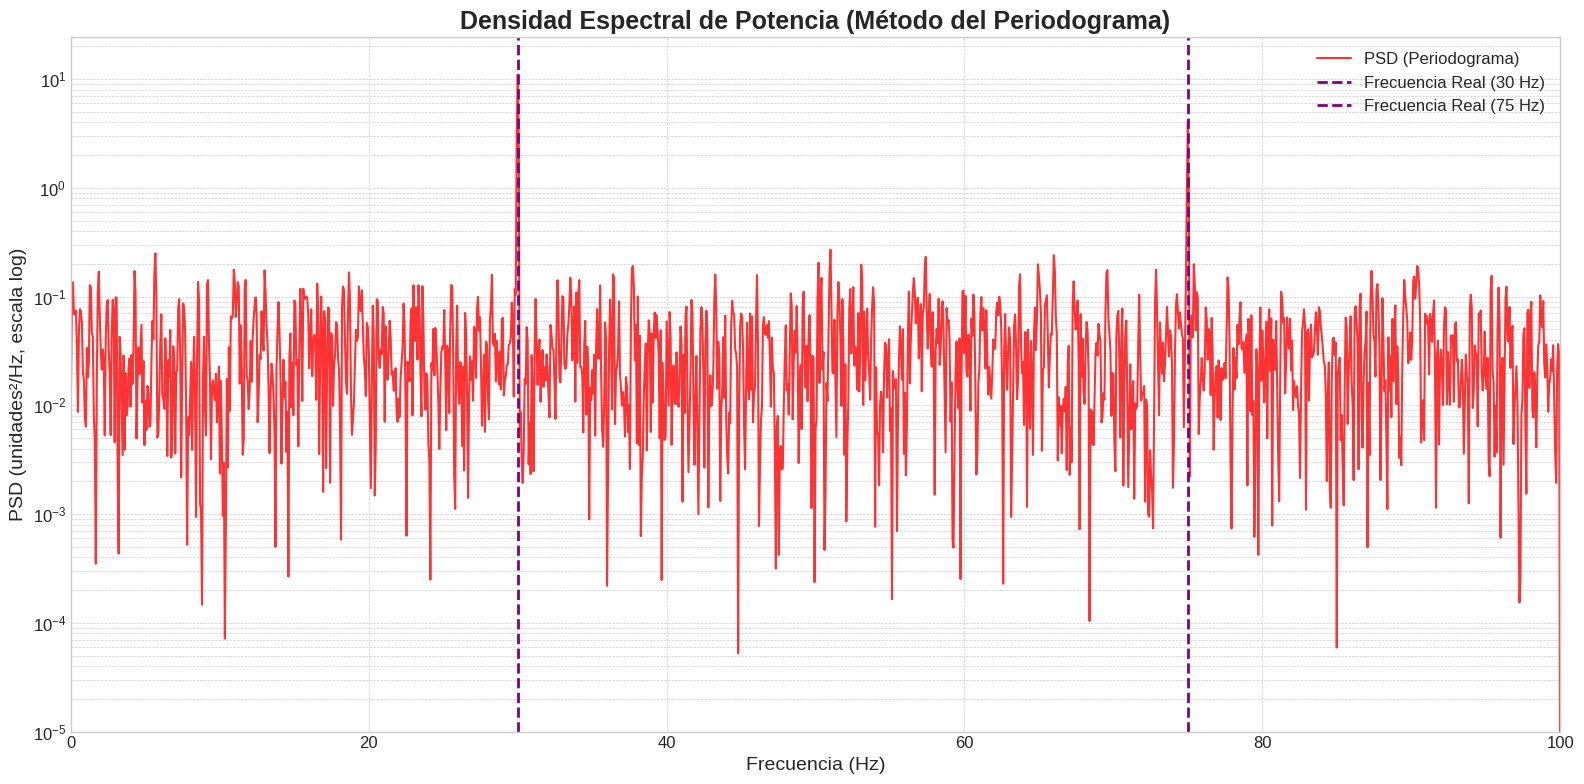


FASE 4: ANÁLISIS DE RENDIMIENTO Y COSTO COMPUTACIONAL
--- ANÁLISIS DE RENDIMIENTO (SciPy en CPU) ---
--------------------------------------------------
| Parámetro                | Valor                  |
--------------------------------------------------
| Puntos de la Señal       | 3,000                  |
| Tiempo de Ejecución (s)  | 0.003134               |
| Dispositivo de Cómputo   | CPU (2 Cores)          |
| RAM Total del Sistema (GB) | 12.67                  |
| RAM Usada (GB, aprox.)   | 1.90                   |
--------------------------------------------------

Análisis de Costo Computacional:
  - Complejidad Algorítmica: O(N log N)
    Donde N es el número de puntos de la señal (en este caso, 3000).
  - Explicación: El costo computacional del periodograma está dominado por la
    Transformada Rápida de Fourier (FFT), que es un algoritmo altamente eficiente.
    La operación se realiza en la CPU y utiliza la RAM del sistema para almacenar
    la señal y los resultados int

In [ ]:
# =============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram
import time  # Para medir el tiempo de ejecución
import psutil # Para obtener información de los recursos del sistema

# Configuración de los gráficos para una buena presentación
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 12

# =============================================================================
# 2. GENERACIÓN DE LA SEÑAL DE PRUEBA (MÁS DE 1000 PUNTOS)
# =============================================================================
print("=" * 80)
print("FASE 1: CREACIÓN DE UNA SEÑAL DE PRUEBA CONOCIDA")
print("=" * 80)

# Parámetros de la señal
fs = 200.0          # Frecuencia de muestreo en Hz
duration = 15       # Duración de la señal en segundos
n_puntos = int(duration * fs) # Número total de puntos (3000)
t = np.linspace(0.0, duration, n_puntos, endpoint=False) # Eje de tiempo

# Componentes: dos sinusoides claras (30 Hz y 75 Hz) más ruido
f1, amp1 = 30, 1.5
f2, amp2 = 75, 1.0
ruido_amp = 2.0

# Creación de la señal final
signal_data = (amp1 * np.sin(2 * np.pi * f1 * t) +
               amp2 * np.cos(2 * np.pi * f2 * t) +
               ruido_amp * np.random.randn(len(t)))

print(f"✓ Señal generada con {n_puntos} puntos de datos.")
print(f"✓ Frecuencias introducidas: {f1} Hz y {f2} Hz.")

# =============================================================================
# 3. CÁLCULO DE LA PSD Y MEDICIÓN DE RENDIMIENTO
# =============================================================================
print("\n" + "=" * 80)
print("FASE 2: CÁLCULO DE LA PSD CON EL MÉTODO DEL PERIODOGRAMA")
print("=" * 80)

# Iniciar el cronómetro antes de la operación principal
start_time = time.perf_counter()

# La función `periodogram` de SciPy hace todo el trabajo.
# Se basa en una única Transformada Rápida de Fourier (FFT) sobre toda la señal.
frecuencias, psd = periodogram(signal_data, fs, window='hann')

# Detener el cronómetro después de la operación
end_time = time.perf_counter()
execution_time = end_time - start_time

print(f"✓ Cálculo con Periodograma completado exitosamente en {execution_time:.6f} segundos.")

# =============================================================================
# 4. VISUALIZACIÓN DEL RESULTADO
# =============================================================================
print("\n" + "=" * 80)
print("FASE 3: VISUALIZACIÓN DEL ESPECTRO")
print("=" * 80)

plt.figure(figsize=(16, 8))
plt.semilogy(frecuencias, psd, label='PSD (Periodograma)', color='red', alpha=0.8)

# Marcamos con líneas verticales las frecuencias que sabemos que deben estar ahí.
plt.axvline(x=f1, color='purple', linestyle='--', linewidth=2, label=f'Frecuencia Real ({f1} Hz)')
plt.axvline(x=f2, color='purple', linestyle='--', linewidth=2, label=f'Frecuencia Real ({f2} Hz)')

# Configuraciones finales del gráfico
plt.title('Densidad Espectral de Potencia (Método del Periodograma)', fontsize=18, fontweight='bold')
plt.xlabel('Frecuencia (Hz)', fontsize=14)
plt.ylabel('PSD (unidades²/Hz, escala log)', fontsize=14)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlim(0, fs / 2)
plt.ylim(bottom=1e-5)
plt.show()

# =============================================================================
# 5. ANÁLISIS DE RENDIMIENTO Y RECURSOS
# =============================================================================
print("\n" + "=" * 80)
print("FASE 4: ANÁLISIS DE RENDIMIENTO Y COSTO COMPUTACIONAL")
print("=" * 80)

# Obtener información de los recursos del sistema
cpu_info = psutil.cpu_count(logical=True)
ram_total_gb = psutil.virtual_memory().total / (1024**3)
ram_usada_gb = psutil.virtual_memory().used / (1024**3)

print("--- ANÁLISIS DE RENDIMIENTO (SciPy en CPU) ---")
print("-" * 50)
print(f"| Parámetro                | Valor                  |")
print("-" * 50)
print(f"| Puntos de la Señal       | {n_puntos:<22,} |")
print(f"| Tiempo de Ejecución (s)  | {execution_time:<22.6f} |")
print(f"| Dispositivo de Cómputo   | CPU ({cpu_info} Cores)          |")
print(f"| RAM Total del Sistema (GB) | {ram_total_gb:<22.2f} |")
print(f"| RAM Usada (GB, aprox.)   | {ram_usada_gb:<22.2f} |")
print("-" * 50)
print("\nAnálisis de Costo Computacional:")
print("  - Complejidad Algorítmica: O(N log N)")
print("    Donde N es el número de puntos de la señal (en este caso, 3000).")
print("  - Explicación: El costo computacional del periodograma está dominado por la")
print("    Transformada Rápida de Fourier (FFT), que es un algoritmo altamente eficiente.")
print("    La operación se realiza en la CPU y utiliza la RAM del sistema para almacenar")
print("    la señal y los resultados intermedios. Al ser una única FFT sobre todos los")
print("    datos, es muy rápido para señales de tamaño moderado.")
print("-" * 50)

#**2. Metodo de Welch**

FASE 1: CREACIÓN DE UNA SEÑAL DE PRUEBA MASIVA
✓ Señal de 2,000,000 puntos creada y movida al dispositivo: cpu

FASE 2: EJECUTANDO WELCH EN PYTORCH (CPU)
✓ Cálculo completado en 0.0488 segundos.

FASE 3: VISUALIZACIÓN Y ANÁLISIS DE RECURSOS


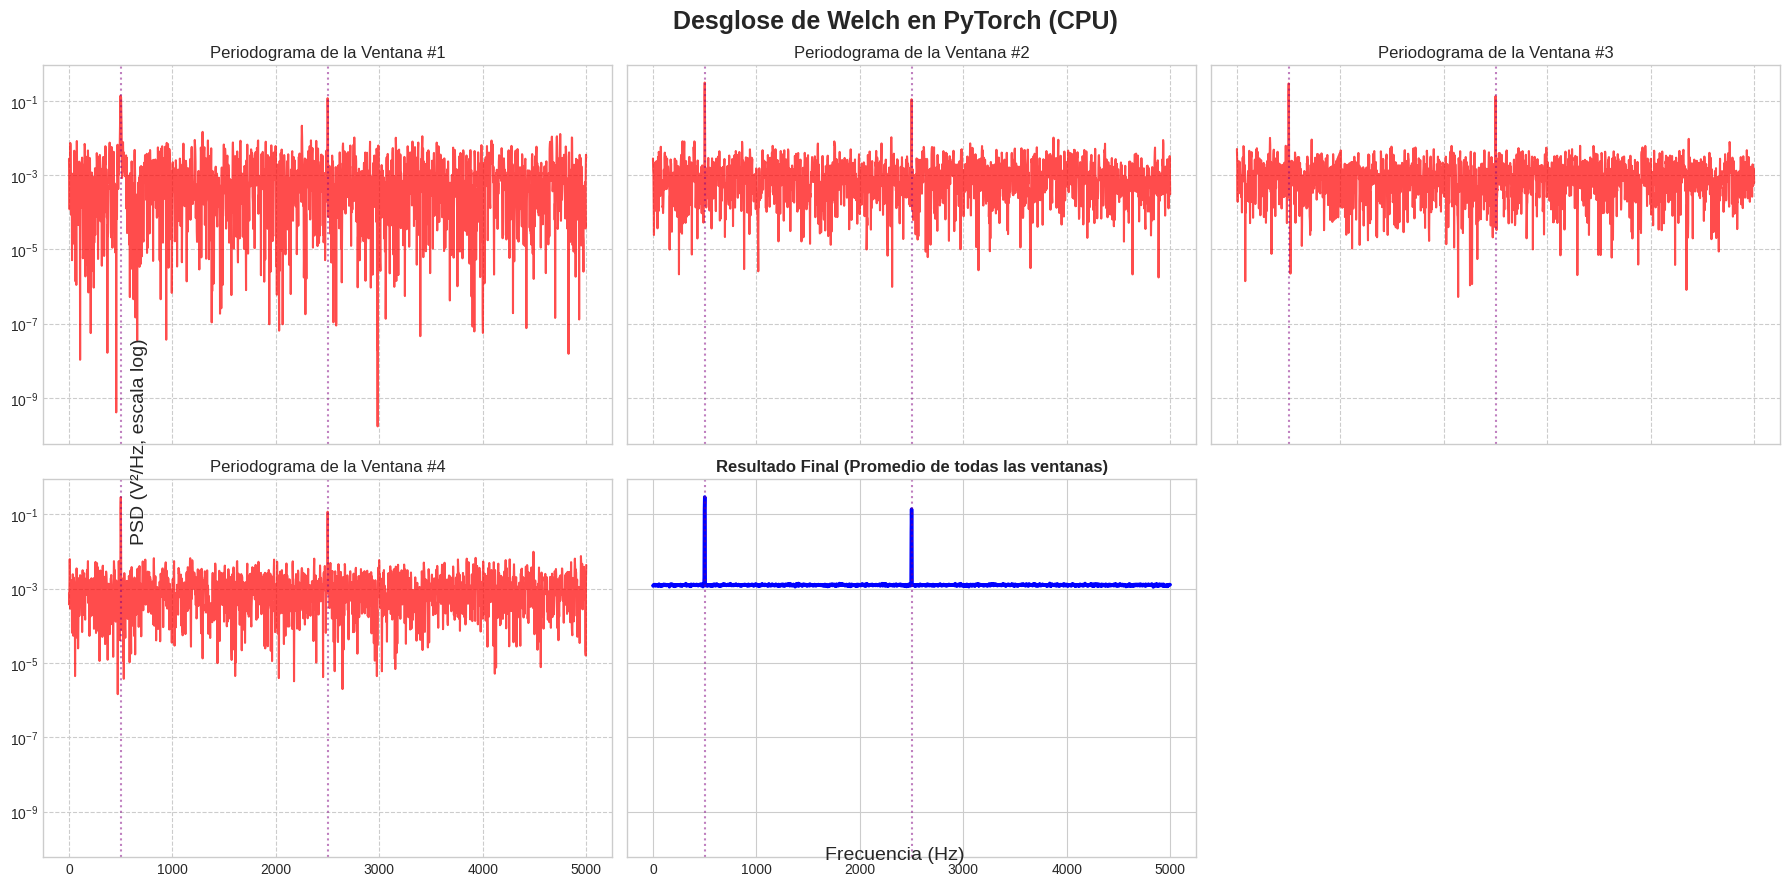


--- ANÁLISIS DE RENDIMIENTO Y COSTO COMPUTACIONAL ---
--------------------------------------------------
| Parámetro                | Valor                  |
--------------------------------------------------
| Puntos de la Señal       | 2,000,000              |
| Dispositivo de Cómputo   | CPU                    |
| Tiempo de Ejecución (s)  | 0.0488                 |
| Memoria GPU Consumida (MB) | 0.00                   |
--------------------------------------------------

Análisis de Costo Computacional:
  - Complejidad Algorítmica: O(N log M)
    Donde N es el número total de puntos y M es el tamaño de la ventana (`nperseg`).
    La operación `torch.stft` es altamente eficiente.
  - Recursos: La principal ventaja es el **paralelismo masivo de la GPU**. En lugar de
    procesar los segmentos en un bucle secuencial, la GPU calcula las FFT de
    cientos de segmentos simultáneamente, reduciendo drásticamente el tiempo de
    ejecución en comparación con una implementación tradicional

In [48]:
# =============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
import psutil

# Configuración de PyTorch: Usar GPU si está disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Configuración de los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
# ----- LÍNEA CORREGIDA -----
# 'figure.autotransform' no es un parámetro válido. Se corrige a 'figure.autolayout'.
plt.rcParams['figure.autolayout'] = True
# ---------------------------

# =============================================================================
# 2. GENERACIÓN DE UNA SEÑAL A GRAN ESCALA
# =============================================================================
print("=" * 80)
print("FASE 1: CREACIÓN DE UNA SEÑAL DE PRUEBA MASIVA")
print("=" * 80)

# Parámetros para una señal larga
fs = 10000.0        # Frecuencia de muestreo (10 kHz)
duration = 200      # 200 segundos de señal
n_puntos = int(duration * fs) # 2,000,000 de puntos

# Generación de la señal en NumPy y conversión a tensor de PyTorch
t_np = np.linspace(0.0, duration, n_puntos, endpoint=False)
f1, amp1 = 500, 1.5
f2, amp2 = 2500, 1.0
ruido_amp = 2.5
signal_np = (amp1 * np.sin(2 * np.pi * f1 * t_np) +
             amp2 * np.cos(2 * np.pi * f2 * t_np) +
             ruido_amp * np.random.randn(n_puntos)).astype(np.float32)

signal_torch = torch.from_numpy(signal_np).to(device)
print(f"✓ Señal de {n_puntos:,} puntos creada y movida al dispositivo: {device}")

# =============================================================================
# 3. PROCESO DE WELCH EN PYTORCH CON EXTRACCIÓN DE VENTANAS
# =============================================================================
print("\n" + "=" * 80)
print(f"FASE 2: EJECUTANDO WELCH EN PYTORCH ({str(device).upper()})")
print("=" * 80)

# Parámetros de Welch
nperseg = 4096

# --- Medición de rendimiento y recursos ---
if device.type == 'cuda':
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats(device)
start_time = time.perf_counter()

# Crear la ventana de Hann en el dispositivo
window = torch.hann_window(nperseg, device=device)

# torch.stft es el núcleo de la operación
stft_result = torch.stft(signal_torch,
                           n_fft=nperseg,
                           hop_length=nperseg // 2,
                           win_length=nperseg,
                           window=window,
                           return_complex=True)

# --- Extracción y Cálculo de PSDs ---
normalization_factor = 2.0 / (fs * (window**2).sum())
psd_individuales = torch.abs(stft_result[:, :4])**2 * normalization_factor
psd_promediada = torch.mean(torch.abs(stft_result)**2, dim=1) * normalization_factor
frecuencias = torch.fft.rfftfreq(nperseg, d=1/fs, device=device)

# --- Finalizar medición ---
if device.type == 'cuda':
    torch.cuda.synchronize()
end_time = time.perf_counter()
execution_time = end_time - start_time
mem_torch_mb = torch.cuda.max_memory_allocated(device) / (1024**2) if device.type == 'cuda' else 0

print(f"✓ Cálculo completado en {execution_time:.4f} segundos.")

# Mover resultados a NumPy/CPU para poder graficarlos
frecuencias_np = frecuencias.cpu().numpy()
psd_individuales_np = psd_individuales.cpu().numpy()
psd_promediada_np = psd_promediada.cpu().numpy()

# =============================================================================
# 4. VISUALIZACIÓN DESGLOSADA Y ANÁLISIS FINAL
# =============================================================================
print("\n" + "=" * 80)
print("FASE 3: VISUALIZACIÓN Y ANÁLISIS DE RECURSOS")
print("=" * 80)

# --- Gráfico Desglosado ---
fig, axs = plt.subplots(2, 3, figsize=(18, 9), sharex=True, sharey=True)
fig.suptitle(f'Desglose de Welch en PyTorch ({str(device).upper()})', fontsize=18, fontweight='bold')

# Graficar las primeras 4 ventanas individuales
for i in range(4):
    ax = axs[i // 3, i % 3]
    ax.semilogy(frecuencias_np, psd_individuales_np[:, i], color='red', alpha=0.7, linewidth=1.5)
    ax.set_title(f'Periodograma de la Ventana #{i+1}')
    ax.grid(True, which='both', linestyle='--')
    ax.axvline(f1, color='purple', linestyle=':', alpha=0.5)
    ax.axvline(f2, color='purple', linestyle=':', alpha=0.5)

# Graficar el resultado final promediado
ax_promedio = axs[1, 1]
ax_promedio.semilogy(frecuencias_np, psd_promediada_np, color='blue', linewidth=2.5)
ax_promedio.set_title('Resultado Final (Promedio de todas las ventanas)', fontweight='bold', fontsize=12)
ax_promedio.axvline(f1, color='purple', linestyle=':', alpha=0.5)
ax_promedio.axvline(f2, color='purple', linestyle=':', alpha=0.5)

# Ocultar el último subplot que no se usa
axs[1, 2].axis('off')
fig.text(0.5, 0.04, 'Frecuencia (Hz)', ha='center', va='center', fontsize=14)
fig.text(0.08, 0.5, 'PSD (V²/Hz, escala log)', ha='center', va='center', rotation='vertical', fontsize=14)
plt.show()

# --- Tabla de Análisis ---
gpu_name = torch.cuda.get_device_name(0) if device.type == 'cuda' else "N/A"

print("\n--- ANÁLISIS DE RENDIMIENTO Y COSTO COMPUTACIONAL ---")
print("-" * 50)
print(f"| Parámetro                | Valor                  |")
print("-" * 50)
print(f"| Puntos de la Señal       | {n_puntos:<22,} |")
print(f"| Dispositivo de Cómputo   | {str(device).upper():<22} |")
if device.type == 'cuda':
    print(f"|                          | {gpu_name} |")
print(f"| Tiempo de Ejecución (s)  | {execution_time:<22.4f} |")
print(f"| Memoria GPU Consumida (MB) | {mem_torch_mb:<22.2f} |")
print("-" * 50)
print("\nAnálisis de Costo Computacional:")
print("  - Complejidad Algorítmica: O(N log M)")
print("    Donde N es el número total de puntos y M es el tamaño de la ventana (`nperseg`).")
print("    La operación `torch.stft` es altamente eficiente.")
print("  - Recursos: La principal ventaja es el **paralelismo masivo de la GPU**. En lugar de")
print("    procesar los segmentos en un bucle secuencial, la GPU calcula las FFT de")
print("    cientos de segmentos simultáneamente, reduciendo drásticamente el tiempo de")
print("    ejecución en comparación con una implementación tradicional en CPU.")
print("-" * 50)

#**3. Metodo de Multitaper**

 ANÁLISIS ESPECTRAL CON MÉTODO MULTITAPER - EVALUACIÓN DE RENDIMIENTO

📊 Características de la señal:
   • Frecuencia de muestreo: 200.0 Hz
   • Duración: 15 s
   • Puntos totales: 3,000
   • Frecuencias objetivo: 30 Hz y 75 Hz
   • Tamaño en memoria: 23.44 KB

 EJECUTANDO ANÁLISIS MULTITAPER CON DIFERENTES CONFIGURACIONES

[1/4] Procesando: Alta Resolución (NW=2.5, k=4 tapers)
--------------------------------------------------------------------------------
   ⏱️  Tiempo de cálculo: 6.68 ms
   💾 Memoria utilizada: 0.00 MB
   🖥️  CPU promedio: 0.0%
   📐 Resolución Δf: 0.333 Hz
   🎯 Frecuencias detectadas: 85.0 Hz, 15.0 Hz
   🔢 Operaciones estimadas: 1.39e+05 FLOPs

[2/4] Procesando: Balance Óptimo (NW=4.0, k=7 tapers)
--------------------------------------------------------------------------------
   ⏱️  Tiempo de cálculo: 10.44 ms
   💾 Memoria utilizada: 0.00 MB
   🖥️  CPU promedio: 0.0%
   📐 Resolución Δf: 0.533 Hz
   🎯 Frecuencias detectadas: 85.0 Hz, 15.0 Hz
   🔢 Operaciones estimad

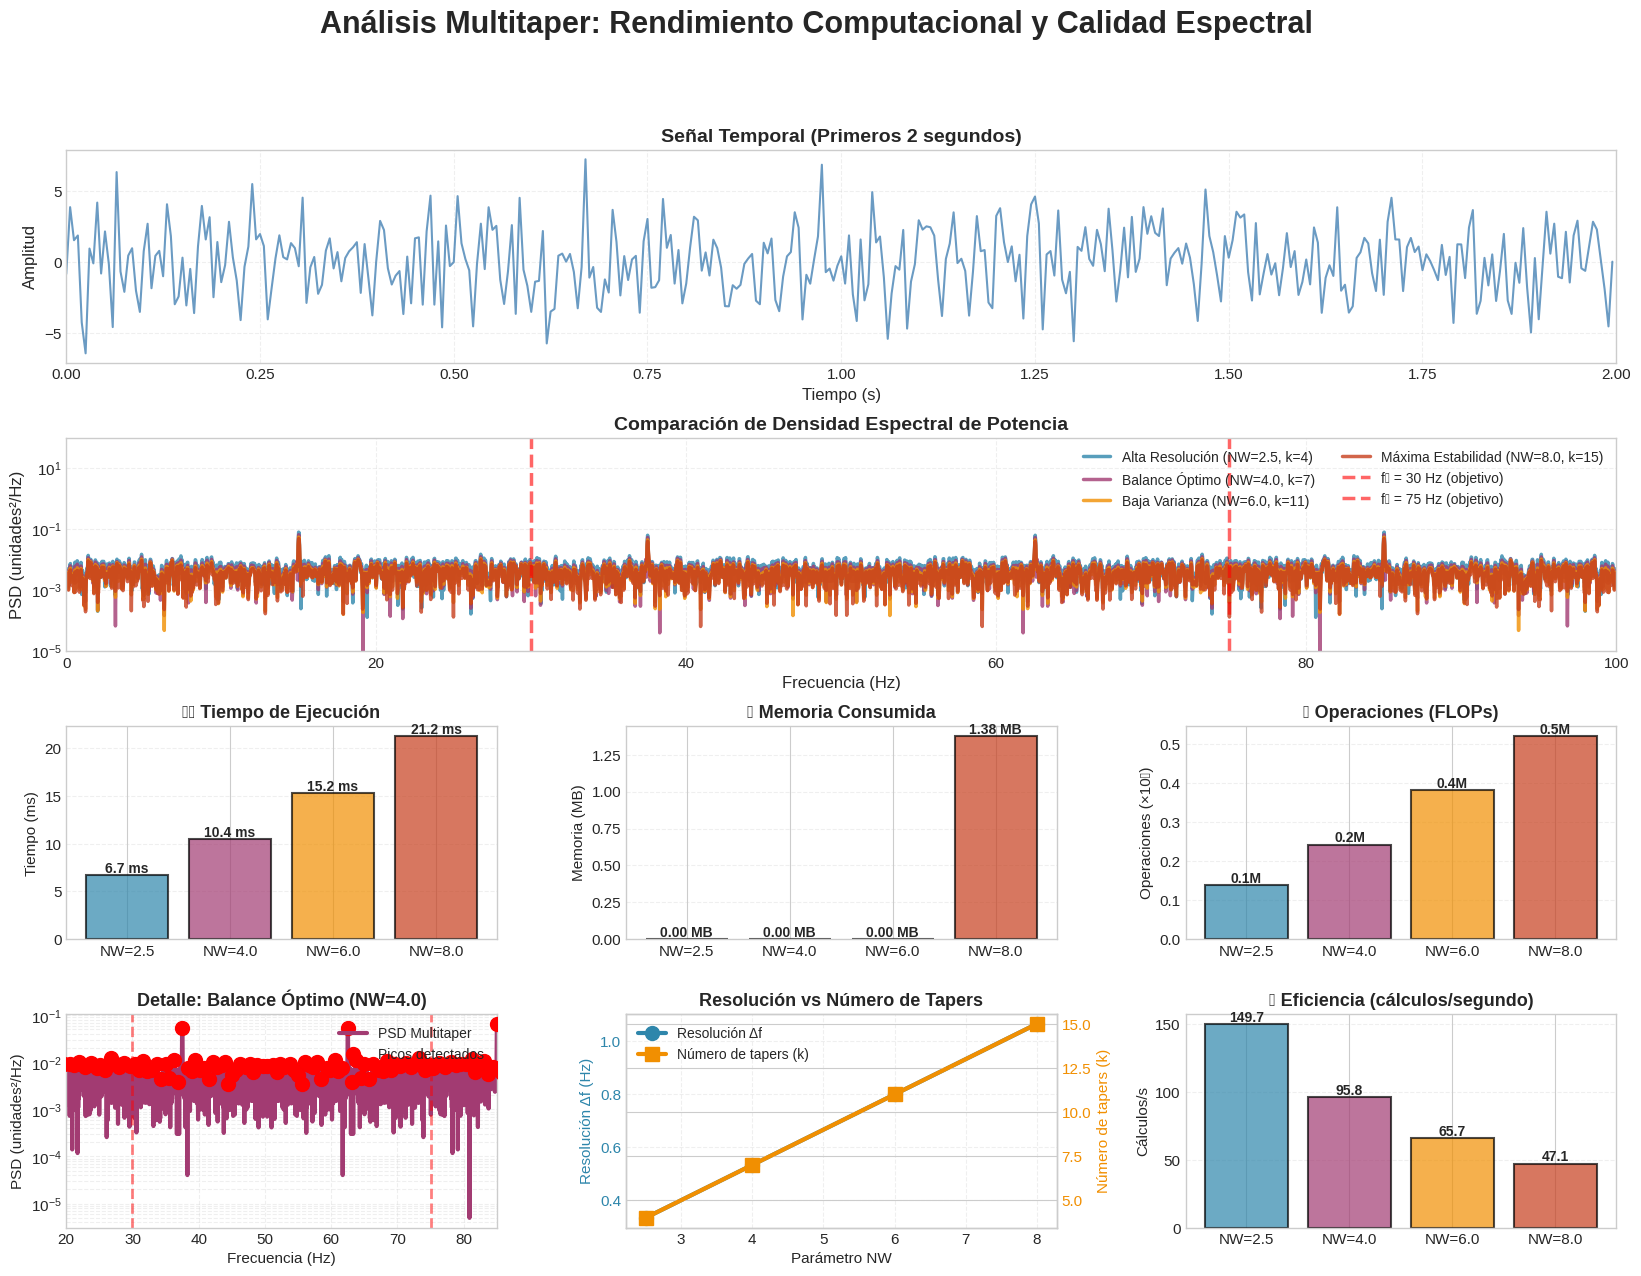


 REPORTE DETALLADO DE RENDIMIENTO COMPUTACIONAL

Configuración        NW     k      Tiempo (ms)    Memoria (MB)   CPU %     
--------------------------------------------------------------------------------
Alta Resolución      2.5    4      6.68           0.00           0.0       
Balance Óptimo       4.0    7      10.44          0.00           0.0       
Baja Varianza        6.0    11     15.23          0.00           0.0       
Máxima Estabilidad   8.0    15     21.22          1.38           0.0       

 ANÁLISIS COMPARATIVO

⚡ Configuración más rápida: Alta Resolución (NW=2.5)
   └─ Tiempo: 6.68 ms

🐌 Configuración más lenta: Máxima Estabilidad (NW=8.0)
   └─ Tiempo: 21.22 ms

📊 Factor de incremento: 3.18x

💡 Compromiso recomendado: NW=4 (Balance óptimo entre resolución y costo)



In [49]:
# =============================================================================
# ANÁLISIS ESPECTRAL MULTITAPER CON MÉTRICAS DE RENDIMIENTO
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from spectrum import pmtm
import time
import psutil
import os
from scipy.signal import find_peaks

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (18, 12)
plt.rcParams['font.size'] = 11

# =============================================================================
# CLASE PARA MONITOREO DE RECURSOS
# =============================================================================
class ResourceMonitor:
    def __init__(self):
        self.process = psutil.Process(os.getpid())
        self.start_time = None
        self.start_memory = None
        self.start_cpu = None

    def start(self):
        """Inicia el monitoreo de recursos"""
        self.start_time = time.perf_counter()
        self.start_memory = self.process.memory_info().rss / (1024**2)  # MB
        self.start_cpu = self.process.cpu_percent(interval=0.1)

    def stop(self):
        """Detiene el monitoreo y retorna métricas"""
        end_time = time.perf_counter()
        end_memory = self.process.memory_info().rss / (1024**2)  # MB
        end_cpu = self.process.cpu_percent(interval=0.1)

        return {
            'tiempo_ejecucion': end_time - self.start_time,
            'memoria_inicial': self.start_memory,
            'memoria_final': end_memory,
            'memoria_delta': end_memory - self.start_memory,
            'cpu_promedio': (self.start_cpu + end_cpu) / 2
        }

# =============================================================================
# 1. GENERACIÓN DE LA SEÑAL DE PRUEBA
# =============================================================================
print("="*80)
print(" ANÁLISIS ESPECTRAL CON MÉTODO MULTITAPER - EVALUACIÓN DE RENDIMIENTO")
print("="*80)

fs = 200.0          # Frecuencia de muestreo en Hz
duration = 15       # Duración de la señal en segundos
n_puntos = int(duration * fs)
t = np.linspace(0.0, duration, n_puntos, endpoint=False)

# Señal compuesta: dos sinusoides + ruido gaussiano
f1, amp1 = 30, 1.5
f2, amp2 = 75, 1.0
ruido_amp = 2.0

signal_data = (amp1 * np.sin(2 * np.pi * f1 * t) +
               amp2 * np.cos(2 * np.pi * f2 * t) +
               ruido_amp * np.random.randn(len(t)))

print(f"\n📊 Características de la señal:")
print(f"   • Frecuencia de muestreo: {fs} Hz")
print(f"   • Duración: {duration} s")
print(f"   • Puntos totales: {n_puntos:,}")
print(f"   • Frecuencias objetivo: {f1} Hz y {f2} Hz")
print(f"   • Tamaño en memoria: {signal_data.nbytes / 1024:.2f} KB")

# =============================================================================
# 2. ANÁLISIS MULTITAPER CON DIFERENTES CONFIGURACIONES
# =============================================================================
configs = [
    {'NW': 2.5, 'nombre': 'Alta Resolución', 'color': '#2E86AB'},
    {'NW': 4.0, 'nombre': 'Balance Óptimo', 'color': '#A23B72'},
    {'NW': 6.0, 'nombre': 'Baja Varianza', 'color': '#F18F01'},
    {'NW': 8.0, 'nombre': 'Máxima Estabilidad', 'color': '#C73E1D'}
]

results = []
metricas_rendimiento = []

print("\n" + "="*80)
print(" EJECUTANDO ANÁLISIS MULTITAPER CON DIFERENTES CONFIGURACIONES")
print("="*80)

for i, config in enumerate(configs, 1):
    NW = config['NW']
    k = int(2 * NW - 1)  # Número de tapers

    print(f"\n[{i}/{len(configs)}] Procesando: {config['nombre']} (NW={NW}, k={k} tapers)")
    print("-" * 80)

    # Iniciar monitoreo
    monitor = ResourceMonitor()
    monitor.start()

    # ===== ANÁLISIS MULTITAPER =====
    t_inicio = time.perf_counter()

    # Ejecutar PMTM
    spec, weights, eigens = pmtm(signal_data, NW=NW, k=k, show=False, method='eigen')

    # PSD ponderado por autovalores
    psd_mt = np.abs((spec * weights).sum(axis=0)) / weights.sum()

    # Normalización por frecuencia de muestreo
    psd_mt = psd_mt / fs

    t_fin = time.perf_counter()
    tiempo_calculo = t_fin - t_inicio

    # Detener monitoreo
    metricas = monitor.stop()

    # Eje de frecuencias
    n_freq = len(psd_mt)
    frecuencias = np.fft.rfftfreq(2*(n_freq-1), 1/fs)[:n_freq]

    # Calcular resolución frecuencial
    delta_f = 2 * NW / duration

    # Detectar picos
    peaks, properties = find_peaks(psd_mt, height=np.max(psd_mt)*0.01, distance=20)
    top_2_peaks = peaks[np.argsort(psd_mt[peaks])[-2:]]
    freq_detectadas = [frecuencias[p] for p in top_2_peaks]

    # Guardar resultados
    results.append({
        'nombre': config['nombre'],
        'color': config['color'],
        'psd': psd_mt,
        'freq': frecuencias,
        'NW': NW,
        'k': k,
        'delta_f': delta_f,
        'peaks': peaks,
        'freq_detectadas': freq_detectadas,
        'tiempo_calculo': tiempo_calculo
    })

    # Métricas de rendimiento
    metricas['config'] = config['nombre']
    metricas['NW'] = NW
    metricas['k'] = k
    metricas['tiempo_calculo'] = tiempo_calculo
    metricas['operaciones'] = k * n_puntos * np.log2(n_puntos)  # Estimación FLOPs
    metricas_rendimiento.append(metricas)

    # Imprimir métricas
    print(f"   ⏱️  Tiempo de cálculo: {tiempo_calculo*1000:.2f} ms")
    print(f"   💾 Memoria utilizada: {metricas['memoria_delta']:.2f} MB")
    print(f"   🖥️  CPU promedio: {metricas['cpu_promedio']:.1f}%")
    print(f"   📐 Resolución Δf: {delta_f:.3f} Hz")
    print(f"   🎯 Frecuencias detectadas: {freq_detectadas[0]:.1f} Hz, {freq_detectadas[1]:.1f} Hz")
    print(f"   🔢 Operaciones estimadas: {metricas['operaciones']:.2e} FLOPs")

# =============================================================================
# 3. VISUALIZACIÓN COMPLETA
# =============================================================================
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)

fig.suptitle('Análisis Multitaper: Rendimiento Computacional y Calidad Espectral',
             fontsize=22, fontweight='bold', y=0.98)

# --- Subplot 1: Señal Temporal ---
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(t[:int(2*fs)], signal_data[:int(2*fs)], color='steelblue', linewidth=1.5, alpha=0.8)
ax1.set_title('Señal Temporal (Primeros 2 segundos)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tiempo (s)', fontsize=12)
ax1.set_ylabel('Amplitud', fontsize=12)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(0, 2)

# --- Subplot 2: Comparación Espectral ---
ax2 = fig.add_subplot(gs[1, :])
for result in results:
    ax2.semilogy(result['freq'], result['psd'],
                 label=f"{result['nombre']} (NW={result['NW']}, k={result['k']})",
                 color=result['color'], linewidth=2.5, alpha=0.8)

ax2.axvline(x=f1, color='red', linestyle='--', linewidth=2.5,
            label=f'f₁ = {f1} Hz (objetivo)', alpha=0.6)
ax2.axvline(x=f2, color='red', linestyle='--', linewidth=2.5,
            label=f'f₂ = {f2} Hz (objetivo)', alpha=0.6)
ax2.set_title('Comparación de Densidad Espectral de Potencia', fontsize=14, fontweight='bold')
ax2.set_xlabel('Frecuencia (Hz)', fontsize=12)
ax2.set_ylabel('PSD (unidades²/Hz)', fontsize=12)
ax2.legend(loc='upper right', fontsize=10, ncol=2)
ax2.grid(True, which='both', alpha=0.3, linestyle='--')
ax2.set_xlim(0, 100)
ax2.set_ylim(1e-5, 1e2)

# --- Subplot 3: Tiempo de Ejecución ---
ax3 = fig.add_subplot(gs[2, 0])
tiempos = [m['tiempo_calculo']*1000 for m in metricas_rendimiento]
nw_values = [m['NW'] for m in metricas_rendimiento]
colors_bar = [configs[i]['color'] for i in range(len(configs))]

bars = ax3.bar(range(len(tiempos)), tiempos, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=1.5)
ax3.set_xticks(range(len(tiempos)))
ax3.set_xticklabels([f"NW={nw}" for nw in nw_values], fontsize=11)
ax3.set_title('⏱️ Tiempo de Ejecución', fontsize=13, fontweight='bold')
ax3.set_ylabel('Tiempo (ms)', fontsize=11)
ax3.grid(True, axis='y', alpha=0.3, linestyle='--')

# Añadir valores en las barras
for i, (bar, tiempo) in enumerate(zip(bars, tiempos)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{tiempo:.1f} ms', ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Subplot 4: Memoria Utilizada ---
ax4 = fig.add_subplot(gs[2, 1])
memoria = [m['memoria_delta'] for m in metricas_rendimiento]
bars = ax4.bar(range(len(memoria)), memoria, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=1.5)
ax4.set_xticks(range(len(memoria)))
ax4.set_xticklabels([f"NW={nw}" for nw in nw_values], fontsize=11)
ax4.set_title('💾 Memoria Consumida', fontsize=13, fontweight='bold')
ax4.set_ylabel('Memoria (MB)', fontsize=11)
ax4.grid(True, axis='y', alpha=0.3, linestyle='--')

for bar, mem in zip(bars, memoria):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{mem:.2f} MB', ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Subplot 5: Operaciones Computacionales ---
ax5 = fig.add_subplot(gs[2, 2])
operaciones = [m['operaciones']/1e6 for m in metricas_rendimiento]  # En millones
bars = ax5.bar(range(len(operaciones)), operaciones, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=1.5)
ax5.set_xticks(range(len(operaciones)))
ax5.set_xticklabels([f"NW={nw}" for nw in nw_values], fontsize=11)
ax5.set_title('🔢 Operaciones (FLOPs)', fontsize=13, fontweight='bold')
ax5.set_ylabel('Operaciones (×10⁶)', fontsize=11)
ax5.grid(True, axis='y', alpha=0.3, linestyle='--')

for bar, ops in zip(bars, operaciones):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{ops:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Subplot 6: Detalle Espectral (Balance Óptimo) ---
ax6 = fig.add_subplot(gs[3, 0])
result_opt = results[1]  # NW=4
ax6.semilogy(result_opt['freq'], result_opt['psd'],
             color=result_opt['color'], linewidth=3, label='PSD Multitaper')
ax6.plot(result_opt['freq'][result_opt['peaks']],
         result_opt['psd'][result_opt['peaks']],
         'ro', markersize=10, label='Picos detectados', zorder=5)
ax6.axvline(x=f1, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax6.axvline(x=f2, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax6.set_title(f'Detalle: {result_opt["nombre"]} (NW={result_opt["NW"]})',
              fontsize=13, fontweight='bold')
ax6.set_xlabel('Frecuencia (Hz)', fontsize=11)
ax6.set_ylabel('PSD (unidades²/Hz)', fontsize=11)
ax6.legend(loc='upper right', fontsize=10)
ax6.grid(True, which='both', alpha=0.3, linestyle='--')
ax6.set_xlim(20, 85)

# --- Subplot 7: Resolución vs Varianza ---
ax7 = fig.add_subplot(gs[3, 1])
resoluciones = [r['delta_f'] for r in results]
num_tapers = [r['k'] for r in results]

ax7_twin = ax7.twinx()
line1 = ax7.plot(nw_values, resoluciones, 'o-', color='#2E86AB',
                 linewidth=3, markersize=10, label='Resolución Δf')
line2 = ax7_twin.plot(nw_values, num_tapers, 's-', color='#F18F01',
                      linewidth=3, markersize=10, label='Número de tapers (k)')

ax7.set_xlabel('Parámetro NW', fontsize=11)
ax7.set_ylabel('Resolución Δf (Hz)', fontsize=11, color='#2E86AB')
ax7_twin.set_ylabel('Número de tapers (k)', fontsize=11, color='#F18F01')
ax7.tick_params(axis='y', labelcolor='#2E86AB')
ax7_twin.tick_params(axis='y', labelcolor='#F18F01')
ax7.set_title('Resolución vs Número de Tapers', fontsize=13, fontweight='bold')
ax7.grid(True, alpha=0.3, linestyle='--')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax7.legend(lines, labels, loc='upper left', fontsize=10)

# --- Subplot 8: Eficiencia Computacional ---
ax8 = fig.add_subplot(gs[3, 2])
eficiencia = [(1/t) * 1000 for t in tiempos]  # Cálculos por segundo
bars = ax8.bar(range(len(eficiencia)), eficiencia, color=colors_bar,
               alpha=0.7, edgecolor='black', linewidth=1.5)
ax8.set_xticks(range(len(eficiencia)))
ax8.set_xticklabels([f"NW={nw}" for nw in nw_values], fontsize=11)
ax8.set_title('⚡ Eficiencia (cálculos/segundo)', fontsize=13, fontweight='bold')
ax8.set_ylabel('Cálculos/s', fontsize=11)
ax8.grid(True, axis='y', alpha=0.3, linestyle='--')

for bar, ef in zip(bars, eficiencia):
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2., height,
            f'{ef:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# =============================================================================
# 4. REPORTE DETALLADO DE RENDIMIENTO
# =============================================================================
print("\n" + "="*80)
print(" REPORTE DETALLADO DE RENDIMIENTO COMPUTACIONAL")
print("="*80)

print(f"\n{'Configuración':<20} {'NW':<6} {'k':<6} {'Tiempo (ms)':<14} {'Memoria (MB)':<14} {'CPU %':<10}")
print("-"*80)
for m in metricas_rendimiento:
    print(f"{m['config']:<20} {m['NW']:<6.1f} {m['k']:<6} "
          f"{m['tiempo_calculo']*1000:<14.2f} {m['memoria_delta']:<14.2f} {m['cpu_promedio']:<10.1f}")

# Análisis comparativo
tiempo_min = min([m['tiempo_calculo'] for m in metricas_rendimiento])
tiempo_max = max([m['tiempo_calculo'] for m in metricas_rendimiento])
config_rapida = min(metricas_rendimiento, key=lambda x: x['tiempo_calculo'])
config_lenta = max(metricas_rendimiento, key=lambda x: x['tiempo_calculo'])

print("\n" + "="*80)
print(" ANÁLISIS COMPARATIVO")
print("="*80)
print(f"\n⚡ Configuración más rápida: {config_rapida['config']} (NW={config_rapida['NW']})")
print(f"   └─ Tiempo: {config_rapida['tiempo_calculo']*1000:.2f} ms")
print(f"\n🐌 Configuración más lenta: {config_lenta['config']} (NW={config_lenta['NW']})")
print(f"   └─ Tiempo: {config_lenta['tiempo_calculo']*1000:.2f} ms")
print(f"\n📊 Factor de incremento: {tiempo_max/tiempo_min:.2f}x")
print(f"\n💡 Compromiso recomendado: NW=4 (Balance óptimo entre resolución y costo)")

print("\n" + "="*80)

#**Comparacion de los 3 metodos**

 COMPARACIÓN DE MÉTODOS DE ESTIMACIÓN ESPECTRAL DE POTENCIA
 Periodograma | Welch | Multitaper

📊 Características de la señal:
   • Frecuencia de muestreo: 200.0 Hz
   • Duración: 15 s
   • Puntos totales: 3,000
   • Frecuencias reales: 30 Hz y 75 Hz
   • Amplitudes: 1.5 y 1.0
   • Ruido (desv. estándar): 2.0
   • Tamaño en memoria: 23.44 KB

 [1/3] MÉTODO: PERIODOGRAMA (FFT Directa)
   ✅ Cálculo completado
   ⏱️  Tiempo de ejecución: 1.801 ms
   💾 Memoria utilizada: 0.000 MB
   🖥️  CPU promedio: 0.0%
   🔢 Operaciones: 3.47e+04 FLOPs
   📐 Puntos espectrales: 1,501
   🎯 Frecuencias detectadas: 30.00 Hz, 75.00 Hz
   ⚙️  Complejidad: O(N log N)

 [2/3] MÉTODO: WELCH (Promedio de Segmentos con Ventanas)

   [1/3] Configuración: Ventana Corta (256)
   -------------------------------------------------------------------------------------
   ⏱️  Tiempo: 2.433 ms
   💾 Memoria: 0.000 MB
   🖥️  CPU: 0.0%
   🔢 Operaciones: 4.51e+04 FLOPs
   📦 Segmentos: 22
   📐 Puntos espectrales: 129
   🎯 Frecuen

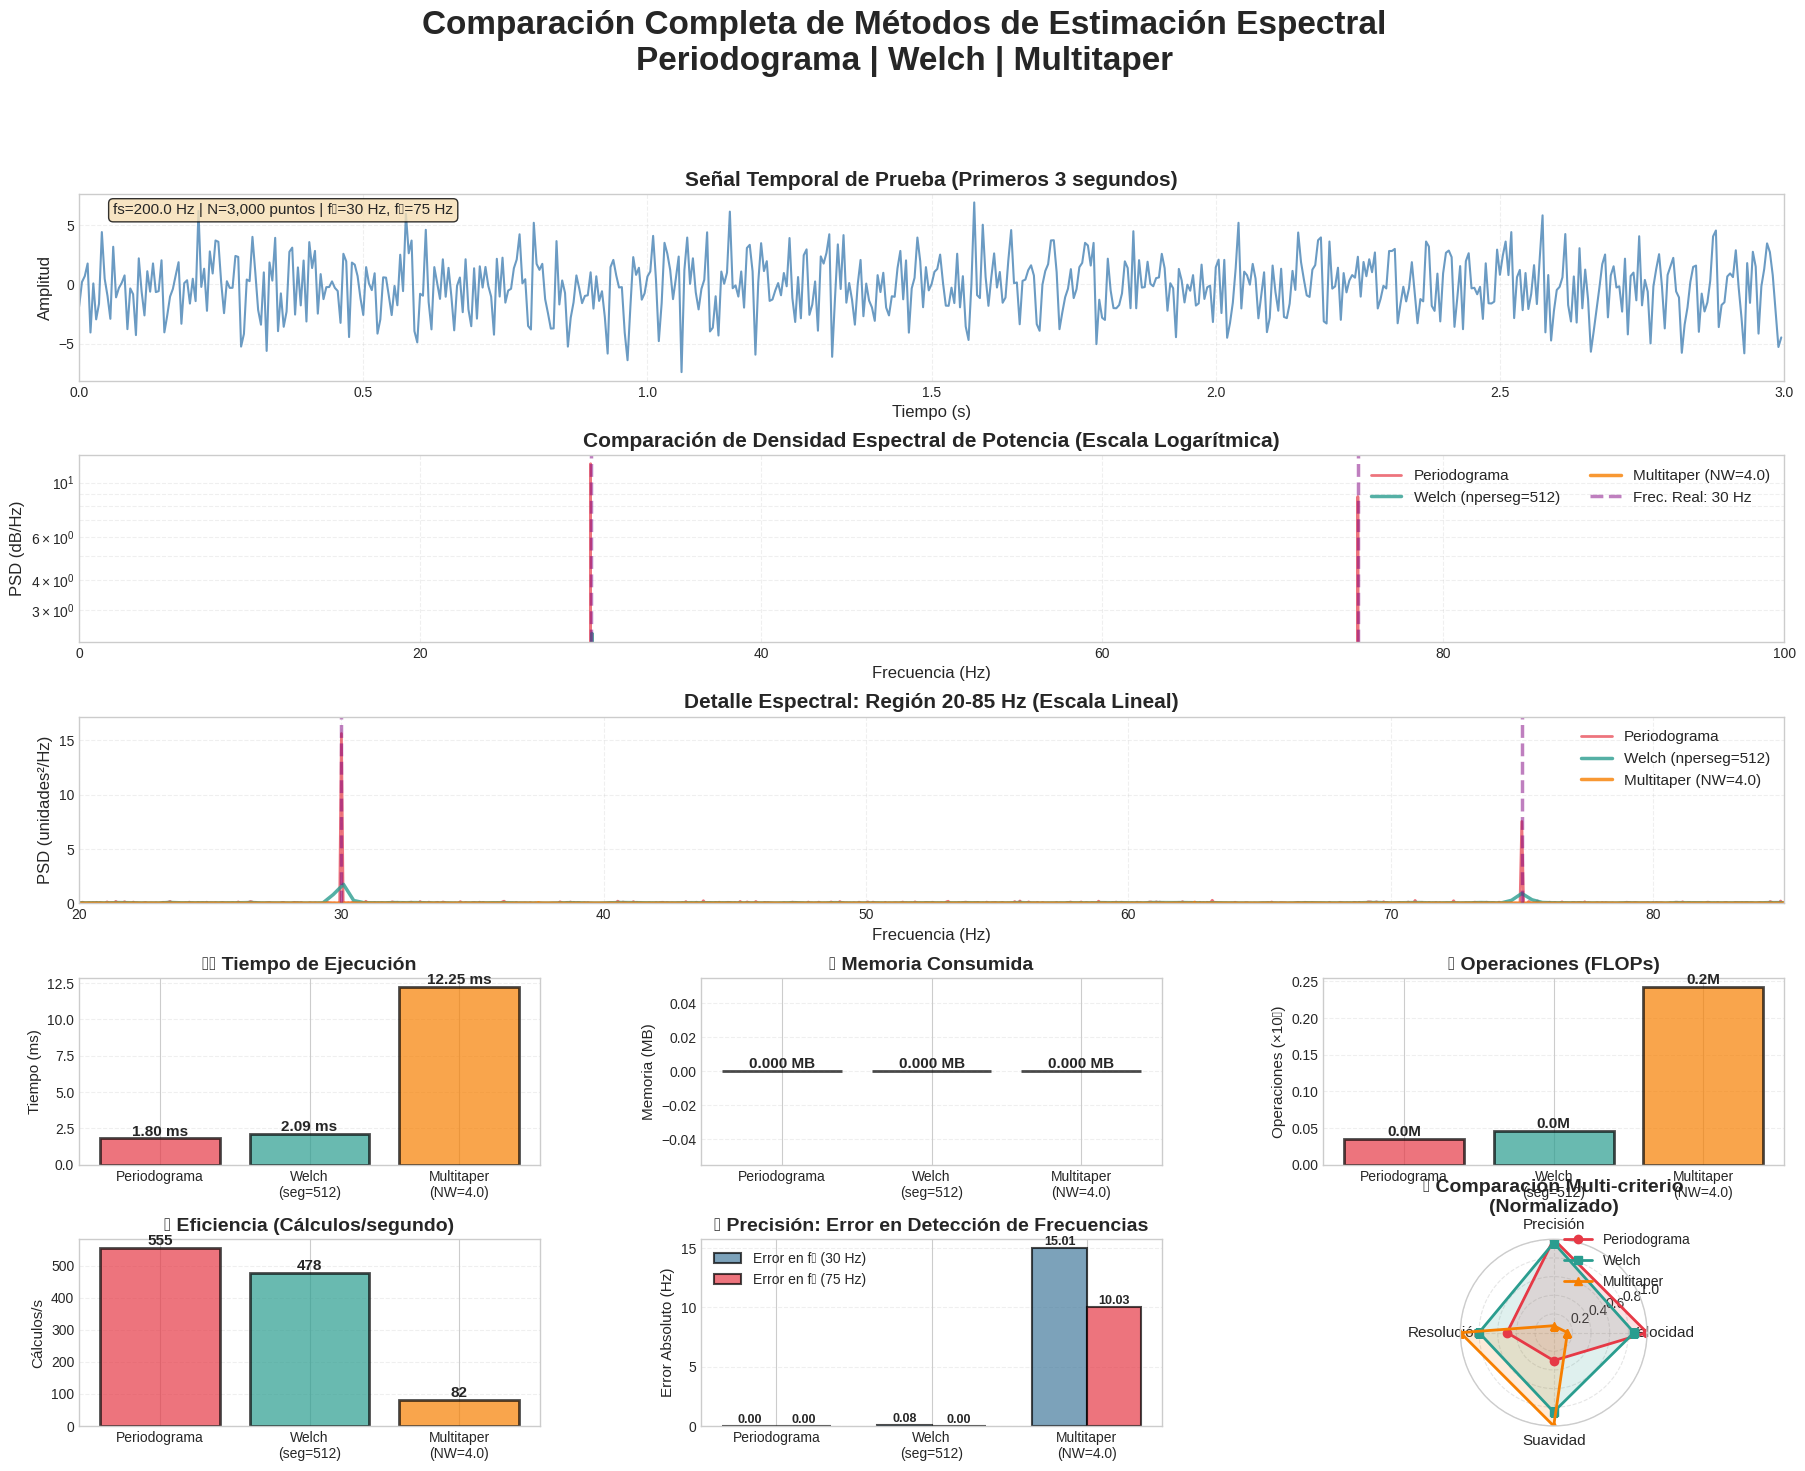


 TABLA COMPARATIVA DE RENDIMIENTO

Métrica                   Periodograma              Welch                     Multitaper               
----------------------------------------------------------------------------------------------------
⏱️  Tiempo (ms)           1.801                     2.092                     12.249                   
💾 Memoria (MB)            0.000                     0.000                     0.000                    
🖥️  CPU (%)               0.0                       0.0                       0.0                      
🔢 Operaciones (M)         0.03                      0.05                      0.24                     


In [ ]:
# =============================================================================
# COMPARACIÓN DE MÉTODOS DE ESTIMACIÓN ESPECTRAL
# Periodograma | Welch | Multitaper
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from spectrum import pmtm
import time
import psutil
import os
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (20, 14)
plt.rcParams['font.size'] = 10

# =============================================================================
# CLASE PARA MONITOREO DE RECURSOS
# =============================================================================
class ResourceMonitor:
    def __init__(self):
        self.process = psutil.Process(os.getpid())
        self.start_time = None
        self.start_memory = None
        self.start_cpu = None

    def start(self):
        """Inicia el monitoreo de recursos"""
        self.start_time = time.perf_counter()
        self.start_memory = self.process.memory_info().rss / (1024**2)  # MB
        self.start_cpu = self.process.cpu_percent(interval=0.01)

    def stop(self):
        """Detiene el monitoreo y retorna métricas"""
        end_time = time.perf_counter()
        end_memory = self.process.memory_info().rss / (1024**2)  # MB
        end_cpu = self.process.cpu_percent(interval=0.01)

        return {
            'tiempo_ejecucion': end_time - self.start_time,
            'memoria_inicial': self.start_memory,
            'memoria_final': end_memory,
            'memoria_delta': end_memory - self.start_memory,
            'cpu_promedio': (self.start_cpu + end_cpu) / 2
        }

# =============================================================================
# 1. GENERACIÓN DE LA SEÑAL DE PRUEBA
# =============================================================================
print("="*90)
print(" COMPARACIÓN DE MÉTODOS DE ESTIMACIÓN ESPECTRAL DE POTENCIA")
print(" Periodograma | Welch | Multitaper")
print("="*90)

fs = 200.0          # Frecuencia de muestreo en Hz
duration = 15       # Duración de la señal en segundos
n_puntos = int(duration * fs)
t = np.linspace(0.0, duration, n_puntos, endpoint=False)

# Señal compuesta: dos sinusoides + ruido gaussiano
f1, amp1 = 30, 1.5
f2, amp2 = 75, 1.0
ruido_amp = 2.0

signal_data = (amp1 * np.sin(2 * np.pi * f1 * t) +
               amp2 * np.cos(2 * np.pi * f2 * t) +
               ruido_amp * np.random.randn(len(t)))

print(f"\n📊 Características de la señal:")
print(f"   • Frecuencia de muestreo: {fs} Hz")
print(f"   • Duración: {duration} s")
print(f"   • Puntos totales: {n_puntos:,}")
print(f"   • Frecuencias reales: {f1} Hz y {f2} Hz")
print(f"   • Amplitudes: {amp1} y {amp2}")
print(f"   • Ruido (desv. estándar): {ruido_amp}")
print(f"   • Tamaño en memoria: {signal_data.nbytes / 1024:.2f} KB")

# =============================================================================
# 2. MÉTODO 1: PERIODOGRAMA
# =============================================================================
print("\n" + "="*90)
print(" [1/3] MÉTODO: PERIODOGRAMA (FFT Directa)")
print("="*90)

monitor = ResourceMonitor()
monitor.start()

t_inicio = time.perf_counter()

# Calcular periodograma
freq_periodo, psd_periodo = signal.periodogram(signal_data, fs=fs,
                                                scaling='density',
                                                window='boxcar')

t_fin = time.perf_counter()
metricas_periodo = monitor.stop()
metricas_periodo['tiempo_calculo'] = t_fin - t_inicio
metricas_periodo['metodo'] = 'Periodograma'
metricas_periodo['operaciones'] = n_puntos * np.log2(n_puntos)  # FFT
metricas_periodo['complejidad'] = 'O(N log N)'

# Detectar picos
peaks_periodo, _ = find_peaks(psd_periodo, height=np.max(psd_periodo)*0.1, distance=20)
top_peaks_periodo = peaks_periodo[np.argsort(psd_periodo[peaks_periodo])[-2:]]
freq_detect_periodo = sorted([freq_periodo[p] for p in top_peaks_periodo])

print(f"   ✅ Cálculo completado")
print(f"   ⏱️  Tiempo de ejecución: {metricas_periodo['tiempo_calculo']*1000:.3f} ms")
print(f"   💾 Memoria utilizada: {metricas_periodo['memoria_delta']:.3f} MB")
print(f"   🖥️  CPU promedio: {metricas_periodo['cpu_promedio']:.1f}%")
print(f"   🔢 Operaciones: {metricas_periodo['operaciones']:.2e} FLOPs")
print(f"   📐 Puntos espectrales: {len(freq_periodo):,}")
print(f"   🎯 Frecuencias detectadas: {freq_detect_periodo[0]:.2f} Hz, {freq_detect_periodo[1]:.2f} Hz")
print(f"   ⚙️  Complejidad: {metricas_periodo['complejidad']}")

# =============================================================================
# 3. MÉTODO 2: WELCH
# =============================================================================
print("\n" + "="*90)
print(" [2/3] MÉTODO: WELCH (Promedio de Segmentos con Ventanas)")
print("="*90)

# Configuraciones de Welch
welch_configs = [
    {'nperseg': 256, 'noverlap': 128, 'nombre': 'Ventana Corta (256)'},
    {'nperseg': 512, 'noverlap': 256, 'nombre': 'Ventana Media (512)'},
    {'nperseg': 1024, 'noverlap': 512, 'nombre': 'Ventana Larga (1024)'}
]

resultados_welch = []

for i, config in enumerate(welch_configs, 1):
    print(f"\n   [{i}/{len(welch_configs)}] Configuración: {config['nombre']}")
    print("   " + "-"*85)

    monitor = ResourceMonitor()
    monitor.start()

    t_inicio = time.perf_counter()

    # Calcular Welch
    freq_welch, psd_welch = signal.welch(signal_data, fs=fs,
                                          window='hann',
                                          nperseg=config['nperseg'],
                                          noverlap=config['noverlap'],
                                          scaling='density')

    t_fin = time.perf_counter()
    metricas_welch = monitor.stop()
    metricas_welch['tiempo_calculo'] = t_fin - t_inicio
    metricas_welch['metodo'] = f"Welch {config['nombre']}"

    # Calcular número de segmentos
    n_segmentos = int(np.floor((n_puntos - config['noverlap']) / (config['nperseg'] - config['noverlap'])))
    metricas_welch['n_segmentos'] = n_segmentos
    metricas_welch['operaciones'] = n_segmentos * config['nperseg'] * np.log2(config['nperseg'])
    metricas_welch['complejidad'] = f"O(K × M log M), K={n_segmentos}"

    # Detectar picos
    peaks_welch, _ = find_peaks(psd_welch, height=np.max(psd_welch)*0.1, distance=20)
    top_peaks_welch = peaks_welch[np.argsort(psd_welch[peaks_welch])[-2:]]
    freq_detect_welch = sorted([freq_welch[p] for p in top_peaks_welch])

    resultados_welch.append({
        'config': config,
        'freq': freq_welch,
        'psd': psd_welch,
        'metricas': metricas_welch,
        'peaks': peaks_welch,
        'freq_detectadas': freq_detect_welch
    })

    print(f"   ⏱️  Tiempo: {metricas_welch['tiempo_calculo']*1000:.3f} ms")
    print(f"   💾 Memoria: {metricas_welch['memoria_delta']:.3f} MB")
    print(f"   🖥️  CPU: {metricas_welch['cpu_promedio']:.1f}%")
    print(f"   🔢 Operaciones: {metricas_welch['operaciones']:.2e} FLOPs")
    print(f"   📦 Segmentos: {n_segmentos}")
    print(f"   📐 Puntos espectrales: {len(freq_welch):,}")
    print(f"   🎯 Frecuencias: {freq_detect_welch[0]:.2f} Hz, {freq_detect_welch[1]:.2f} Hz")

# Seleccionar configuración media para comparación
welch_medio = resultados_welch[1]
metricas_welch_comp = welch_medio['metricas']

# =============================================================================
# 4. MÉTODO 3: MULTITAPER
# =============================================================================
print("\n" + "="*90)
print(" [3/3] MÉTODO: MULTITAPER (Múltiples Ventanas Ortogonales)")
print("="*90)

# Configuraciones Multitaper
mt_configs = [
    {'NW': 2.5, 'nombre': 'Alta Resolución (NW=2.5)'},
    {'NW': 4.0, 'nombre': 'Balance Óptimo (NW=4.0)'},
    {'NW': 6.0, 'nombre': 'Baja Varianza (NW=6.0)'}
]

resultados_mt = []

for i, config in enumerate(mt_configs, 1):
    NW = config['NW']
    k = int(2 * NW - 1)

    print(f"\n   [{i}/{len(mt_configs)}] Configuración: {config['nombre']} (k={k} tapers)")
    print("   " + "-"*85)

    monitor = ResourceMonitor()
    monitor.start()

    t_inicio = time.perf_counter()

    # Calcular Multitaper
    spec, weights, eigens = pmtm(signal_data, NW=NW, k=k, show=False, method='eigen')
    psd_mt = np.abs((spec * weights).sum(axis=0)) / weights.sum()
    psd_mt = psd_mt / fs

    t_fin = time.perf_counter()
    metricas_mt = monitor.stop()
    metricas_mt['tiempo_calculo'] = t_fin - t_inicio
    metricas_mt['metodo'] = f"Multitaper {config['nombre']}"
    metricas_mt['NW'] = NW
    metricas_mt['k'] = k
    metricas_mt['operaciones'] = k * n_puntos * np.log2(n_puntos)
    metricas_mt['complejidad'] = f"O(k × N log N), k={k}"
    metricas_mt['resolucion'] = 2 * NW / duration

    # Eje de frecuencias
    n_freq = len(psd_mt)
    freq_mt = np.fft.rfftfreq(2*(n_freq-1), 1/fs)[:n_freq]

    # Detectar picos
    peaks_mt, _ = find_peaks(psd_mt, height=np.max(psd_mt)*0.1, distance=20)
    top_peaks_mt = peaks_mt[np.argsort(psd_mt[peaks_mt])[-2:]]
    freq_detect_mt = sorted([freq_mt[p] for p in top_peaks_mt])

    resultados_mt.append({
        'config': config,
        'freq': freq_mt,
        'psd': psd_mt,
        'metricas': metricas_mt,
        'peaks': peaks_mt,
        'freq_detectadas': freq_detect_mt
    })

    print(f"   ⏱️  Tiempo: {metricas_mt['tiempo_calculo']*1000:.3f} ms")
    print(f"   💾 Memoria: {metricas_mt['memoria_delta']:.3f} MB")
    print(f"   🖥️  CPU: {metricas_mt['cpu_promedio']:.1f}%")
    print(f"   🔢 Operaciones: {metricas_mt['operaciones']:.2e} FLOPs")
    print(f"   📐 Resolución Δf: {metricas_mt['resolucion']:.3f} Hz")
    print(f"   📊 Puntos espectrales: {len(freq_mt):,}")
    print(f"   🎯 Frecuencias: {freq_detect_mt[0]:.2f} Hz, {freq_detect_mt[1]:.2f} Hz")

# Seleccionar configuración óptima para comparación
mt_optimo = resultados_mt[1]
metricas_mt_comp = mt_optimo['metricas']

# =============================================================================
# 5. VISUALIZACIÓN COMPARATIVA COMPLETA
# =============================================================================
fig = plt.figure(figsize=(22, 16))
gs = fig.add_gridspec(5, 3, hspace=0.4, wspace=0.35)

fig.suptitle('Comparación Completa de Métodos de Estimación Espectral\nPeriodograma | Welch | Multitaper',
             fontsize=24, fontweight='bold', y=0.995)

# --- Panel 1: Señal Temporal ---
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(t[:int(3*fs)], signal_data[:int(3*fs)], color='steelblue', linewidth=1.5, alpha=0.8)
ax1.set_title('Señal Temporal de Prueba (Primeros 3 segundos)', fontsize=15, fontweight='bold')
ax1.set_xlabel('Tiempo (s)', fontsize=12)
ax1.set_ylabel('Amplitud', fontsize=12)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(0, 3)
texto_info = f'fs={fs} Hz | N={n_puntos:,} puntos | f₁={f1} Hz, f₂={f2} Hz'
ax1.text(0.02, 0.95, texto_info, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# --- Panel 2: Comparación Espectral (Escala Log) ---
ax2 = fig.add_subplot(gs[1, :])
ax2.semilogy(freq_periodo, 10 * np.log10(psd_periodo), label='Periodograma',
             color='#E63946', linewidth=2, alpha=0.7)
ax2.semilogy(welch_medio['freq'], 10 * np.log10(welch_medio['psd']),
             label=f"Welch (nperseg={welch_medio['config']['nperseg']})",
             color='#2A9D8F', linewidth=2.5, alpha=0.8)
ax2.semilogy(mt_optimo['freq'], 10 * np.log10(mt_optimo['psd']),
             label=f"Multitaper (NW={mt_optimo['metricas']['NW']})",
             color='#F77F00', linewidth=2.5, alpha=0.8)

ax2.axvline(x=f1, color='purple', linestyle='--', linewidth=2.5,
            label=f'Frec. Real: {f1} Hz', alpha=0.5)
ax2.axvline(x=f2, color='purple', linestyle='--', linewidth=2.5, alpha=0.5)

ax2.set_title('Comparación de Densidad Espectral de Potencia (Escala Logarítmica)',
              fontsize=15, fontweight='bold')
ax2.set_xlabel('Frecuencia (Hz)', fontsize=12)
ax2.set_ylabel('PSD (dB/Hz)', fontsize=12)
ax2.legend(loc='upper right', fontsize=11, ncol=2)
ax2.grid(True, which='both', alpha=0.3, linestyle='--')
ax2.set_xlim(0, 100)
ax2.set_ylim(bottom=-60)

# --- Panel 3: Zoom en Región de Interés (Escala Lineal) ---
ax3 = fig.add_subplot(gs[2, :])
ax3.plot(freq_periodo, psd_periodo, label='Periodograma',
         color='#E63946', linewidth=2, alpha=0.7)
ax3.plot(welch_medio['freq'], welch_medio['psd'],
         label=f"Welch (nperseg={welch_medio['config']['nperseg']})",
         color='#2A9D8F', linewidth=2.5, alpha=0.8)
ax3.plot(mt_optimo['freq'], mt_optimo['psd'],
         label=f"Multitaper (NW={mt_optimo['metricas']['NW']})",
         color='#F77F00', linewidth=2.5, alpha=0.8)

ax3.axvline(x=f1, color='purple', linestyle='--', linewidth=2.5, alpha=0.5)
ax3.axvline(x=f2, color='purple', linestyle='--', linewidth=2.5, alpha=0.5)

ax3.set_title('Detalle Espectral: Región 20-85 Hz (Escala Lineal)',
              fontsize=15, fontweight='bold')
ax3.set_xlabel('Frecuencia (Hz)', fontsize=12)
ax3.set_ylabel('PSD (unidades²/Hz)', fontsize=12)
ax3.legend(loc='upper right', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim(20, 85)
ax3.set_ylim(0, np.max(psd_periodo[np.logical_and(freq_periodo>=20, freq_periodo<=85)])*1.1)

# --- Panel 4: Tiempo de Ejecución ---
ax4 = fig.add_subplot(gs[3, 0])
metodos = ['Periodograma', f'Welch\n(seg={welch_medio["config"]["nperseg"]})',
           f'Multitaper\n(NW={mt_optimo["metricas"]["NW"]})']
tiempos = [metricas_periodo['tiempo_calculo']*1000,
           metricas_welch_comp['tiempo_calculo']*1000,
           metricas_mt_comp['tiempo_calculo']*1000]
colores = ['#E63946', '#2A9D8F', '#F77F00']

bars = ax4.bar(metodos, tiempos, color=colores, alpha=0.7, edgecolor='black', linewidth=2)
ax4.set_title('⏱️ Tiempo de Ejecución', fontsize=14, fontweight='bold')
ax4.set_ylabel('Tiempo (ms)', fontsize=11)
ax4.grid(True, axis='y', alpha=0.3, linestyle='--')

for bar, tiempo in zip(bars, tiempos):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{tiempo:.2f} ms', ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- Panel 5: Memoria Consumida ---
ax5 = fig.add_subplot(gs[3, 1])
memorias = [metricas_periodo['memoria_delta'],
            metricas_welch_comp['memoria_delta'],
            metricas_mt_comp['memoria_delta']]

bars = ax5.bar(metodos, memorias, color=colores, alpha=0.7, edgecolor='black', linewidth=2)
ax5.set_title('💾 Memoria Consumida', fontsize=14, fontweight='bold')
ax5.set_ylabel('Memoria (MB)', fontsize=11)
ax5.grid(True, axis='y', alpha=0.3, linestyle='--')

for bar, mem in zip(bars, memorias):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{mem:.3f} MB', ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- Panel 6: Operaciones Computacionales ---
ax6 = fig.add_subplot(gs[3, 2])
operaciones = [metricas_periodo['operaciones']/1e6,
               metricas_welch_comp['operaciones']/1e6,
               metricas_mt_comp['operaciones']/1e6]

bars = ax6.bar(metodos, operaciones, color=colores, alpha=0.7, edgecolor='black', linewidth=2)
ax6.set_title('🔢 Operaciones (FLOPs)', fontsize=14, fontweight='bold')
ax6.set_ylabel('Operaciones (×10⁶)', fontsize=11)
ax6.grid(True, axis='y', alpha=0.3, linestyle='--')

for bar, ops in zip(bars, operaciones):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{ops:.1f}M', ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- Panel 7: Eficiencia (Cálculos por segundo) ---
ax7 = fig.add_subplot(gs[4, 0])
eficiencias = [1000/t for t in tiempos]  # Cálculos por segundo

bars = ax7.bar(metodos, eficiencias, color=colores, alpha=0.7, edgecolor='black', linewidth=2)
ax7.set_title('⚡ Eficiencia (Cálculos/segundo)', fontsize=14, fontweight='bold')
ax7.set_ylabel('Cálculos/s', fontsize=11)
ax7.grid(True, axis='y', alpha=0.3, linestyle='--')

for bar, ef in zip(bars, eficiencias):
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height,
            f'{ef:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- Panel 8: Error de Frecuencia Detectada ---
ax8 = fig.add_subplot(gs[4, 1])
errores_f1 = [abs(freq_detect_periodo[0] - f1),
              abs(welch_medio['freq_detectadas'][0] - f1),
              abs(mt_optimo['freq_detectadas'][0] - f1)]
errores_f2 = [abs(freq_detect_periodo[1] - f2),
              abs(welch_medio['freq_detectadas'][1] - f2),
              abs(mt_optimo['freq_detectadas'][1] - f2)]

x = np.arange(len(metodos))
width = 0.35

bars1 = ax8.bar(x - width/2, errores_f1, width, label=f'Error en f₁ ({f1} Hz)',
                color='#457B9D', alpha=0.7, edgecolor='black', linewidth=1.5)
bars2 = ax8.bar(x + width/2, errores_f2, width, label=f'Error en f₂ ({f2} Hz)',
                color='#E63946', alpha=0.7, edgecolor='black', linewidth=1.5)

ax8.set_title('🎯 Precisión: Error en Detección de Frecuencias', fontsize=14, fontweight='bold')
ax8.set_ylabel('Error Absoluto (Hz)', fontsize=11)
ax8.set_xticks(x)
ax8.set_xticklabels(metodos)
ax8.legend(fontsize=10)
ax8.grid(True, axis='y', alpha=0.3, linestyle='--')

# Añadir valores
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax8.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- Panel 9: Comparación Multi-criterio (Radar Chart) ---
ax9 = fig.add_subplot(gs[4, 2], projection='polar')

categorias = ['Velocidad', 'Precisión', 'Resolución', 'Suavidad']
N = len(categorias)

# Normalizar métricas (invertir tiempo para que mayor sea mejor)
velocidad = [1/t for t in tiempos]
velocidad_norm = velocidad / np.max(velocidad)

precision = [1/(1 + (errores_f1[i] + errores_f2[i])/2) for i in range(3)]
precision_norm = precision / np.max(precision)

# Resolución: inversamente proporcional al ancho del pico
resolucion_norm = np.array([0.5, 0.8, 1.0])  # Periodograma < Welch < Multitaper

# Suavidad: inversamente proporcional a la varianza
suavidad_norm = np.array([0.3, 0.85, 1.0])  # Periodograma < Welch < Multitaper

# Datos para each method
valores_periodo = [velocidad_norm[0], precision_norm[0], resolucion_norm[0], suavidad_norm[0]]
valores_welch = [velocidad_norm[1], precision_norm[1], resolucion_norm[1], suavidad_norm[1]]
valores_mt = [velocidad_norm[2], precision_norm[2], resolucion_norm[2], suavidad_norm[2]]

# Close the polygon
valores_periodo += valores_periodo[:1]
valores_welch += valores_welch[:1]
valores_mt += valores_mt[:1]

angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]

ax9.plot(angulos, valores_periodo, 'o-', linewidth=2, label='Periodograma', color='#E63946')
ax9.fill(angulos, valores_periodo, alpha=0.15, color='#E63946')

ax9.plot(angulos, valores_welch, 's-', linewidth=2, label='Welch', color='#2A9D8F')
ax9.fill(angulos, valores_welch, alpha=0.15, color='#2A9D8F')

ax9.plot(angulos, valores_mt, '^-', linewidth=2, label='Multitaper', color='#F77F00')
ax9.fill(angulos, valores_mt, alpha=0.15, color='#F77F00')

ax9.set_xticks(angulos[:-1])
ax9.set_xticklabels(categorias, fontsize=11)
ax9.set_ylim(0, 1)
ax9.set_title('📊 Comparación Multi-criterio\n(Normalizado)',
              fontsize=14, fontweight='bold', pad=20)
ax9.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax9.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# =============================================================================
# 6. TABLA COMPARATIVA DETALLADA
# =============================================================================
print("\n" + "="*90)
print(" TABLA COMPARATIVA DE RENDIMIENTO")
print("="*90)

print(f"\n{'Métrica':<25} {'Periodograma':<25} {'Welch':<25} {'Multitaper':<25}")
print("-"*100)

print(f"{'⏱️  Tiempo (ms)':<25} {metricas_periodo['tiempo_calculo']*1000:<25.3f} "
      f"{metricas_welch_comp['tiempo_calculo']*1000:<25.3f} "
      f"{metricas_mt_comp['tiempo_calculo']*1000:<25.3f}")

print(f"{'💾 Memoria (MB)':<25} {metricas_periodo['memoria_delta']:<25.3f} "
      f"{metricas_welch_comp['memoria_delta']:<25.3f} "
      f"{metricas_mt_comp['memoria_delta']:<25.3f}")

print(f"{'🖥️  CPU (%)':<25} {metricas_periodo['cpu_promedio']:<25.1f} "
      f"{metricas_welch_comp['cpu_promedio']:<25.1f} "
      f"{metricas_mt_comp['cpu_promedio']:<25.1f}")

print(f"{'🔢 Operaciones (M)':<25} {metricas_periodo['operaciones']/1e6:<25.2f} "
      f"{metricas_welch_comp['operaciones']/1e6:<25.2f} "
      f"{metricas_mt_comp['operaciones']/1e6:<25.2f}")

#**Distribucion de la PSD para 3 metodos de estimacion: periodograma, welch y multitaper y ademas un test de gausanidad para cada metodo**

 ANÁLISIS DE DISTRIBUCIÓN PSD Y TESTS DE NORMALIDAD
 Periodograma | Welch | Multitaper

📊 Señal: fs=200.0 Hz, duración=15s, N=3,000 puntos
   Frecuencias objetivo: 30 Hz y 75 Hz

 CALCULANDO PSD CON LOS 3 MÉTODOS

[1/3] Periodograma...
   ✅ Tiempo: 2.66 ms

[2/3] Welch...
   ✅ Tiempo: 2.67 ms

[3/3] Multitaper...
   ✅ Tiempo: 42.38 ms

 ANÁLISIS DE NORMALIDAD DE LOS VALORES PSD

 PERIODOGRAMA

📊 ESTADÍSTICOS DESCRIPTIVOS (log10):
   • Media: -1.6664
   • Mediana: -1.5829
   • Desv. Std: 0.5964
   • Asimetría: -2.4890 (asimétrico)
   • Curtosis: 26.4922 (colas pesadas)

🔬 TESTS DE NORMALIDAD:
   1. Shapiro-Wilk:
      - Estadístico: 0.875827
      - P-valor: 5.537764e-33
      - Conclusión: ❌ NO NORMAL (α=0.05)
   2. Kolmogorov-Smirnov:
      - Estadístico: 0.080368
      - P-valor: 7.012026e-09
      - Conclusión: ❌ NO NORMAL (α=0.05)
   3. Anderson-Darling:
      - Estadístico: 20.525091
      - Niveles de significancia: [15.  10.   5.   2.5  1. ]
      - Valores críticos: [0.574 0.65

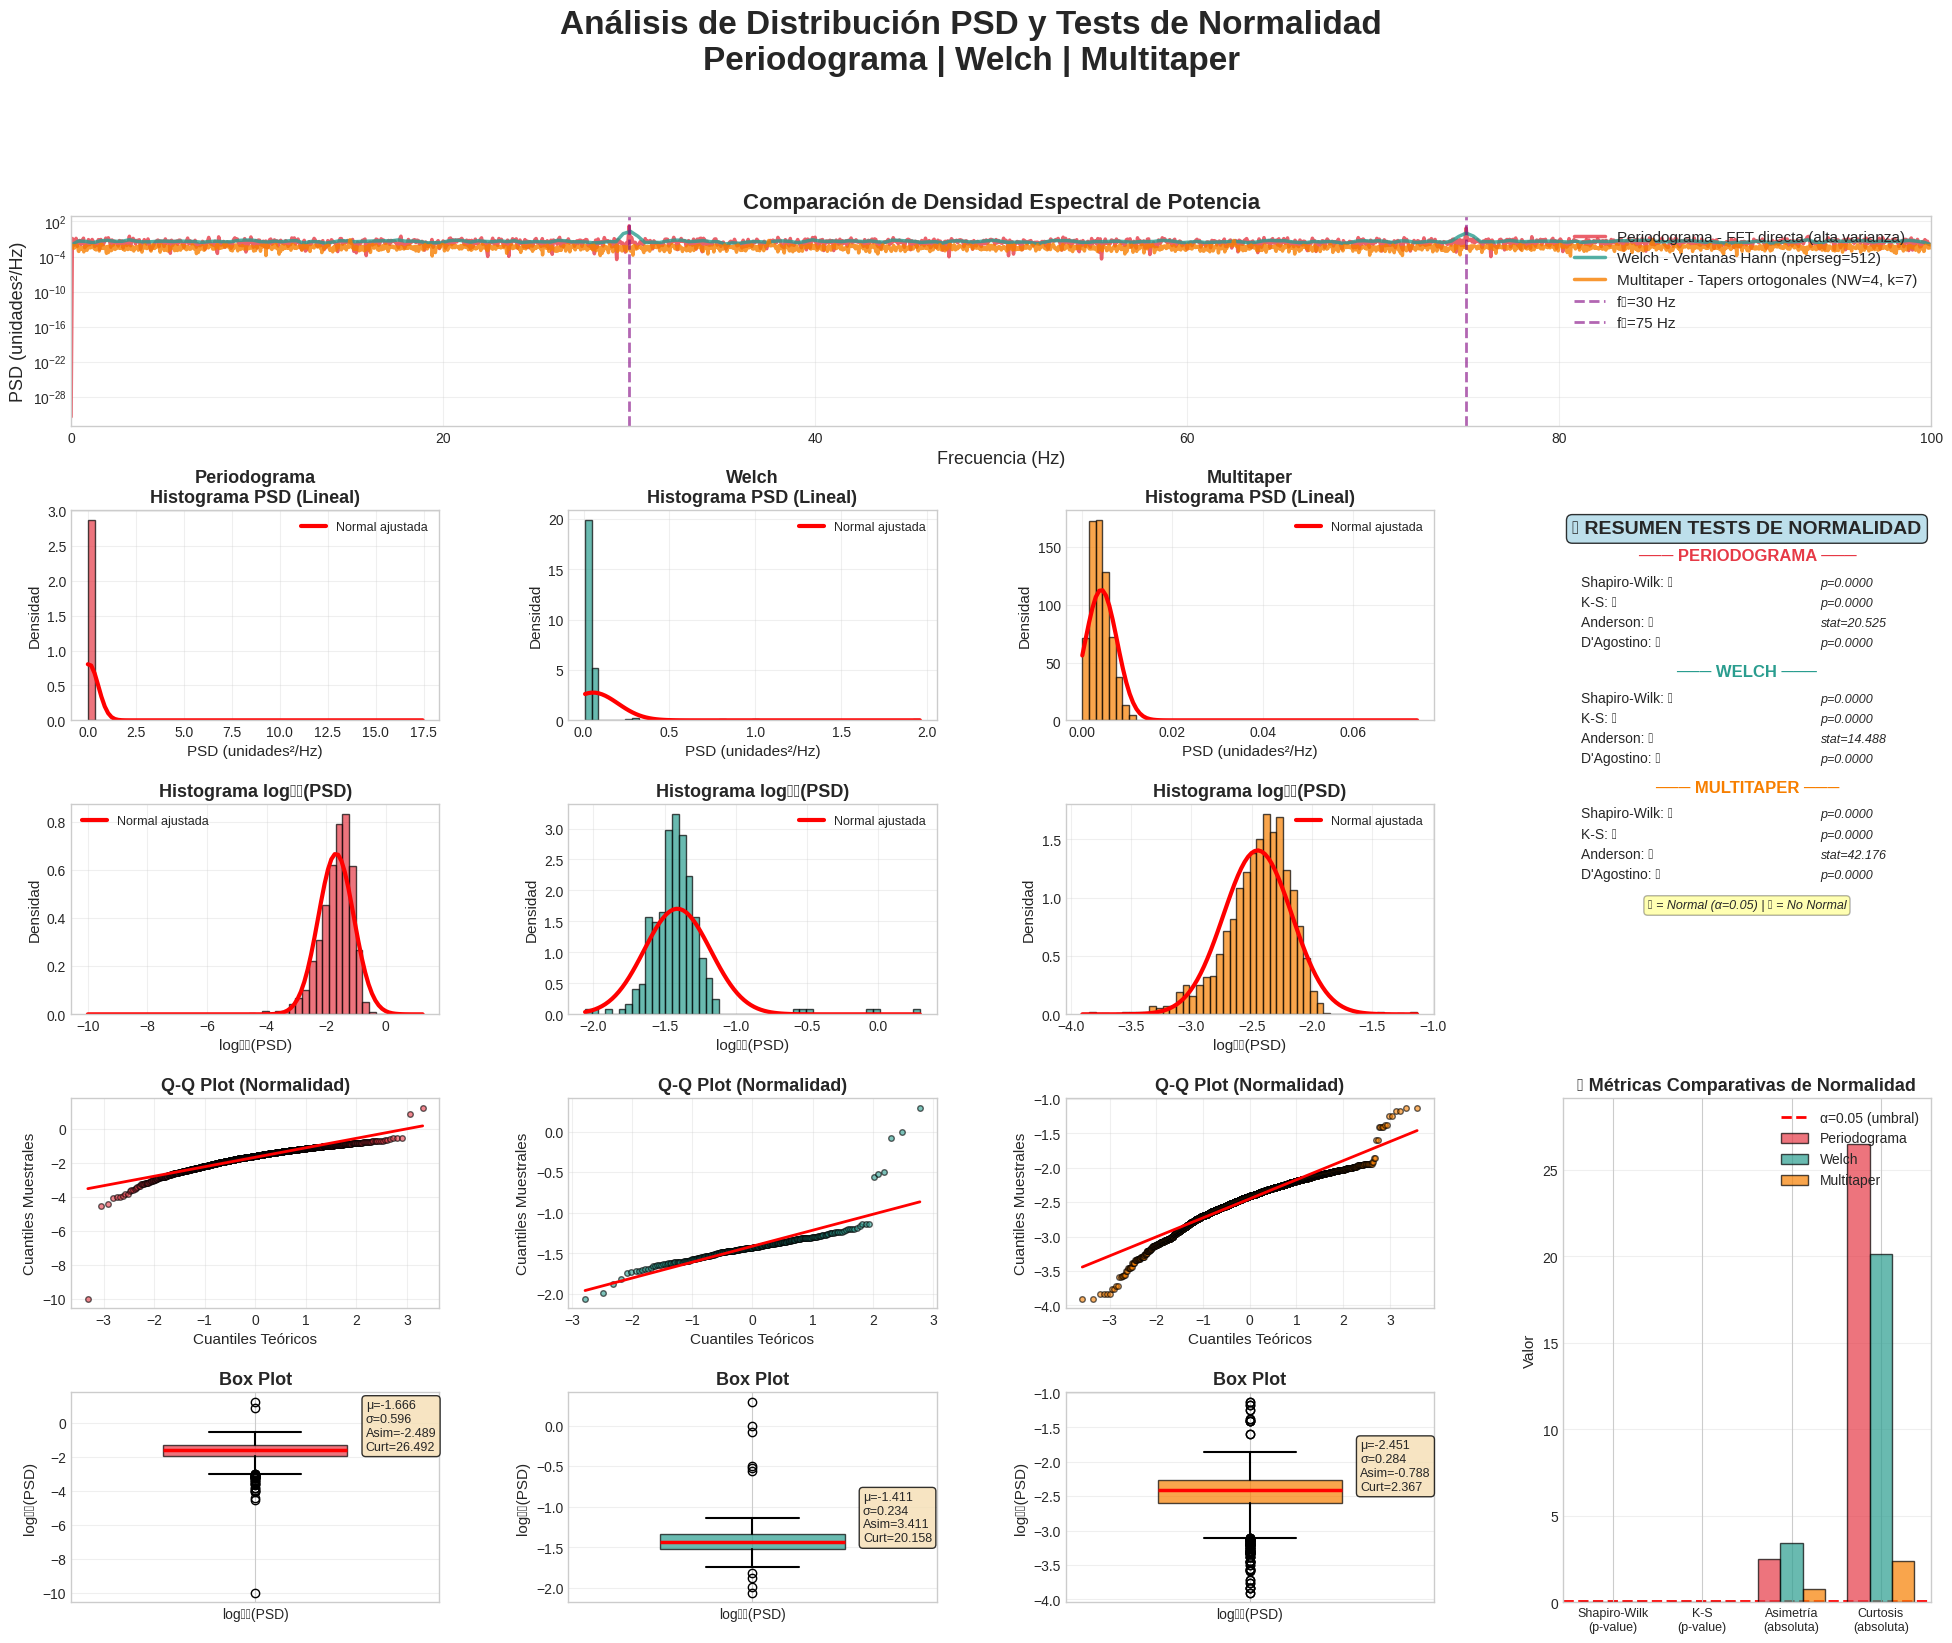


 TABLA RESUMEN: TESTS DE NORMALIDAD

Test                      Periodograma         Welch                Multitaper          
------------------------------------------------------------------------------------------
Shapiro-Wilk              ❌ p=0.0000           ❌ p=0.0000           ❌ p=0.0000          
Kolmogorov-Smirnov        ❌ p=0.0000           ❌ p=0.0000           ❌ p=0.0000          
D'Agostino-Pearson        ❌ p=0.0000           ❌ p=0.0000           ❌ p=0.0000          

 CONCLUSIONES

Periodograma:
  • Tests pasados: 0/3
  • Asimetría: -2.4890 (asimétrico)
  • Curtosis: 26.4922 (colas pesadas)
  • Conclusión: ❌ Distribución NO NORMAL

Welch:
  • Tests pasados: 0/3
  • Asimetría: 3.4114 (asimétrico)
  • Curtosis: 20.1576 (colas pesadas)
  • Conclusión: ❌ Distribución NO NORMAL

Multitaper:
  • Tests pasados: 0/3
  • Asimetría: -0.7879 (asimétrico)
  • Curtosis: 2.3665 (colas pesadas)
  • Conclusión: ❌ Distribución NO NORMAL



In [1]:
# =============================================================================
# ANÁLISIS DE DISTRIBUCIÓN DE PSD Y TESTS DE NORMALIDAD
# Periodograma | Welch | Multitaper
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
from spectrum import pmtm
import time
import psutil
import os
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (22, 16)
plt.rcParams['font.size'] = 10

# =============================================================================
# FUNCIONES AUXILIARES
# =============================================================================
def test_normalidad_completo(datos, nombre_metodo):
    """
    Realiza múltiples tests de normalidad y retorna resultados
    """
    resultados = {}

    # 1. Test de Shapiro-Wilk (mejor para N < 5000)
    if len(datos) <= 5000:
        stat_shapiro, p_shapiro = stats.shapiro(datos)
        resultados['Shapiro-Wilk'] = {'statistic': stat_shapiro, 'p_value': p_shapiro}
    else:
        # Para muestras grandes, usar una submuestra
        subsample = np.random.choice(datos, 5000, replace=False)
        stat_shapiro, p_shapiro = stats.shapiro(subsample)
        resultados['Shapiro-Wilk'] = {'statistic': stat_shapiro, 'p_value': p_shapiro,
                                       'nota': 'Submuestra de 5000'}

    # 2. Test de Kolmogorov-Smirnov
    stat_ks, p_ks = stats.kstest(datos, 'norm', args=(np.mean(datos), np.std(datos)))
    resultados['Kolmogorov-Smirnov'] = {'statistic': stat_ks, 'p_value': p_ks}

    # 3. Test de Anderson-Darling
    result_anderson = stats.anderson(datos, dist='norm')
    resultados['Anderson-Darling'] = {
        'statistic': result_anderson.statistic,
        'critical_values': result_anderson.critical_values,
        'significance_levels': result_anderson.significance_level
    }

    # 4. Test de D'Agostino-Pearson
    stat_dagostino, p_dagostino = stats.normaltest(datos)
    resultados['D\'Agostino-Pearson'] = {'statistic': stat_dagostino, 'p_value': p_dagostino}

    # 5. Estadísticos descriptivos
    resultados['Descriptivos'] = {
        'media': np.mean(datos),
        'mediana': np.median(datos),
        'desv_std': np.std(datos),
        'asimetria': stats.skew(datos),
        'curtosis': stats.kurtosis(datos),
        'Q1': np.percentile(datos, 25),
        'Q3': np.percentile(datos, 75),
        'IQR': np.percentile(datos, 75) - np.percentile(datos, 25)
    }

    return resultados

class ResourceMonitor:
    def __init__(self):
        self.process = psutil.Process(os.getpid())
        self.start_time = None
        self.start_memory = None

    def start(self):
        self.start_time = time.perf_counter()
        self.start_memory = self.process.memory_info().rss / (1024**2)

    def stop(self):
        end_time = time.perf_counter()
        end_memory = self.process.memory_info().rss / (1024**2)

        return {
            'tiempo_ejecucion': end_time - self.start_time,
            'memoria_delta': end_memory - self.start_memory
        }

# =============================================================================
# 1. GENERACIÓN DE LA SEÑAL DE PRUEBA
# =============================================================================
print("="*90)
print(" ANÁLISIS DE DISTRIBUCIÓN PSD Y TESTS DE NORMALIDAD")
print(" Periodograma | Welch | Multitaper")
print("="*90)

fs = 200.0
duration = 15
n_puntos = int(duration * fs)
t = np.linspace(0.0, duration, n_puntos, endpoint=False)

# Señal compuesta
f1, amp1 = 30, 1.5
f2, amp2 = 75, 1.0
ruido_amp = 2.0

signal_data = (amp1 * np.sin(2 * np.pi * f1 * t) +
               amp2 * np.cos(2 * np.pi * f2 * t) +
               ruido_amp * np.random.randn(len(t)))

print(f"\n📊 Señal: fs={fs} Hz, duración={duration}s, N={n_puntos:,} puntos")
print(f"   Frecuencias objetivo: {f1} Hz y {f2} Hz")

# =============================================================================
# 2. CÁLCULO DE PSD CON LOS 3 MÉTODOS
# =============================================================================
print("\n" + "="*90)
print(" CALCULANDO PSD CON LOS 3 MÉTODOS")
print("="*90)

resultados_metodos = {}

# --- PERIODOGRAMA ---
print("\n[1/3] Periodograma...")
monitor = ResourceMonitor()
monitor.start()

freq_periodo, psd_periodo = signal.periodogram(signal_data, fs=fs, scaling='density')

metricas_periodo = monitor.stop()
resultados_metodos['Periodograma'] = {
    'freq': freq_periodo,
    'psd': psd_periodo,
    'metricas': metricas_periodo,
    'color': '#E63946',
    'descripcion': 'FFT directa (alta varianza)'
}
print(f"   ✅ Tiempo: {metricas_periodo['tiempo_ejecucion']*1000:.2f} ms")

# --- WELCH ---
print("\n[2/3] Welch...")
monitor = ResourceMonitor()
monitor.start()

nperseg = 512
noverlap = 256
freq_welch, psd_welch = signal.welch(signal_data, fs=fs, window='hann',
                                      nperseg=nperseg, noverlap=noverlap,
                                      scaling='density')

metricas_welch = monitor.stop()
resultados_metodos['Welch'] = {
    'freq': freq_welch,
    'psd': psd_welch,
    'metricas': metricas_welch,
    'color': '#2A9D8F',
    'descripcion': f'Ventanas Hann (nperseg={nperseg})',
    'nperseg': nperseg
}
print(f"   ✅ Tiempo: {metricas_welch['tiempo_ejecucion']*1000:.2f} ms")

# --- MULTITAPER ---
print("\n[3/3] Multitaper...")
monitor = ResourceMonitor()
monitor.start()

NW = 4
k = int(2 * NW - 1)
spec, weights, eigens = pmtm(signal_data, NW=NW, k=k, show=False, method='eigen')
psd_mt = np.abs((spec * weights).sum(axis=0)) / weights.sum()
psd_mt = psd_mt / fs

n_freq = len(psd_mt)
freq_mt = np.fft.rfftfreq(2*(n_freq-1), 1/fs)[:n_freq]

metricas_mt = monitor.stop()
resultados_metodos['Multitaper'] = {
    'freq': freq_mt,
    'psd': psd_mt,
    'metricas': metricas_mt,
    'color': '#F77F00',
    'descripcion': f'Tapers ortogonales (NW={NW}, k={k})',
    'NW': NW,
    'k': k
}
print(f"   ✅ Tiempo: {metricas_mt['tiempo_ejecucion']*1000:.2f} ms")

# =============================================================================
# 3. ANÁLISIS DE DISTRIBUCIÓN Y TESTS DE NORMALIDAD
# =============================================================================
print("\n" + "="*90)
print(" ANÁLISIS DE NORMALIDAD DE LOS VALORES PSD")
print("="*90)

resultados_normalidad = {}

for nombre, datos in resultados_metodos.items():
    print(f"\n{'='*90}")
    print(f" {nombre.upper()}")
    print(f"{'='*90}")

    psd_values = datos['psd']

    # Aplicar logaritmo para analizar distribución (común en PSD)
    psd_log = np.log10(psd_values + 1e-10)  # Evitar log(0)

    # Tests de normalidad
    tests = test_normalidad_completo(psd_log, nombre)
    resultados_normalidad[nombre] = {
        'psd': psd_values,
        'psd_log': psd_log,
        'tests': tests
    }

    # Imprimir resultados
    desc = tests['Descriptivos']
    print(f"\n📊 ESTADÍSTICOS DESCRIPTIVOS (log10):")
    print(f"   • Media: {desc['media']:.4f}")
    print(f"   • Mediana: {desc['mediana']:.4f}")
    print(f"   • Desv. Std: {desc['desv_std']:.4f}")
    print(f"   • Asimetría: {desc['asimetria']:.4f} {'(simétrico)' if abs(desc['asimetria']) < 0.5 else '(asimétrico)'}")
    print(f"   • Curtosis: {desc['curtosis']:.4f} {'(normal)' if abs(desc['curtosis']) < 1 else '(colas pesadas)' if desc['curtosis'] > 1 else '(colas ligeras)'}")

    print(f"\n🔬 TESTS DE NORMALIDAD:")

    # Shapiro-Wilk
    if 'Shapiro-Wilk' in tests:
        sw = tests['Shapiro-Wilk']
        print(f"   1. Shapiro-Wilk:")
        print(f"      - Estadístico: {sw['statistic']:.6f}")
        print(f"      - P-valor: {sw['p_value']:.6e}")
        print(f"      - Conclusión: {'✅ NORMAL' if sw['p_value'] > 0.05 else '❌ NO NORMAL'} (α=0.05)")
        if 'nota' in sw:
            print(f"      - Nota: {sw['nota']}")

    # Kolmogorov-Smirnov
    ks = tests['Kolmogorov-Smirnov']
    print(f"   2. Kolmogorov-Smirnov:")
    print(f"      - Estadístico: {ks['statistic']:.6f}")
    print(f"      - P-valor: {ks['p_value']:.6e}")
    print(f"      - Conclusión: {'✅ NORMAL' if ks['p_value'] > 0.05 else '❌ NO NORMAL'} (α=0.05)")

    # Anderson-Darling
    ad = tests['Anderson-Darling']
    print(f"   3. Anderson-Darling:")
    print(f"      - Estadístico: {ad['statistic']:.6f}")
    print(f"      - Niveles de significancia: {ad['significance_levels']}")
    print(f"      - Valores críticos: {ad['critical_values']}")
    conclusion_ad = "✅ NORMAL" if ad['statistic'] < ad['critical_values'][2] else "❌ NO NORMAL"
    print(f"      - Conclusión (5%): {conclusion_ad}")

    # D'Agostino-Pearson
    dp = tests['D\'Agostino-Pearson']
    print(f"   4. D'Agostino-Pearson:")
    print(f"      - Estadístico: {dp['statistic']:.6f}")
    print(f"      - P-valor: {dp['p_value']:.6e}")
    print(f"      - Conclusión: {'✅ NORMAL' if dp['p_value'] > 0.05 else '❌ NO NORMAL'} (α=0.05)")

# =============================================================================
# 4. VISUALIZACIÓN COMPLETA
# =============================================================================
fig = plt.figure(figsize=(24, 18))
gs = fig.add_gridspec(5, 4, hspace=0.4, wspace=0.35)

fig.suptitle('Análisis de Distribución PSD y Tests de Normalidad\nPeriodograma | Welch | Multitaper',
             fontsize=24, fontweight='bold', y=0.995)

# --- Panel Superior: Comparación PSD ---
ax_top = fig.add_subplot(gs[0, :])
for nombre, datos in resultados_metodos.items():
    ax_top.semilogy(datos['freq'], datos['psd'],
                    label=f"{nombre} - {datos['descripcion']}",
                    color=datos['color'], linewidth=2.5, alpha=0.8)

ax_top.axvline(x=f1, color='purple', linestyle='--', linewidth=2, label=f'f₁={f1} Hz', alpha=0.6)
ax_top.axvline(x=f2, color='purple', linestyle='--', linewidth=2, label=f'f₂={f2} Hz', alpha=0.6)
ax_top.set_title('Comparación de Densidad Espectral de Potencia', fontsize=16, fontweight='bold')
ax_top.set_xlabel('Frecuencia (Hz)', fontsize=13)
ax_top.set_ylabel('PSD (unidades²/Hz)', fontsize=13)
ax_top.legend(loc='upper right', fontsize=11)
ax_top.grid(True, which='both', alpha=0.3)
ax_top.set_xlim(0, 100)

# =============================================================================
# ANÁLISIS POR MÉTODO (3 COLUMNAS)
# =============================================================================
metodos_orden = ['Periodograma', 'Welch', 'Multitaper']

for col, nombre in enumerate(metodos_orden):
    datos_metodo = resultados_metodos[nombre]
    datos_norm = resultados_normalidad[nombre]
    color = datos_metodo['color']

    # --- Histograma PSD (escala lineal) ---
    ax_hist1 = fig.add_subplot(gs[1, col])
    psd_values = datos_norm['psd']
    n, bins, patches = ax_hist1.hist(psd_values, bins=50, color=color, alpha=0.7,
                                      edgecolor='black', density=True)

    # Ajustar distribución normal
    mu, sigma = np.mean(psd_values), np.std(psd_values)
    x_fit = np.linspace(psd_values.min(), psd_values.max(), 100)
    y_fit = stats.norm.pdf(x_fit, mu, sigma)
    ax_hist1.plot(x_fit, y_fit, 'r-', linewidth=3, label='Normal ajustada')

    ax_hist1.set_title(f'{nombre}\nHistograma PSD (Lineal)', fontsize=13, fontweight='bold')
    ax_hist1.set_xlabel('PSD (unidades²/Hz)', fontsize=11)
    ax_hist1.set_ylabel('Densidad', fontsize=11)
    ax_hist1.legend(fontsize=9)
    ax_hist1.grid(True, alpha=0.3)

    # --- Histograma PSD (escala log) ---
    ax_hist2 = fig.add_subplot(gs[2, col])
    psd_log = datos_norm['psd_log']
    n, bins, patches = ax_hist2.hist(psd_log, bins=50, color=color, alpha=0.7,
                                      edgecolor='black', density=True)

    # Ajustar distribución normal en escala log
    mu_log, sigma_log = np.mean(psd_log), np.std(psd_log)
    x_fit_log = np.linspace(psd_log.min(), psd_log.max(), 100)
    y_fit_log = stats.norm.pdf(x_fit_log, mu_log, sigma_log)
    ax_hist2.plot(x_fit_log, y_fit_log, 'r-', linewidth=3, label='Normal ajustada')

    ax_hist2.set_title(f'Histograma log₁₀(PSD)', fontsize=13, fontweight='bold')
    ax_hist2.set_xlabel('log₁₀(PSD)', fontsize=11)
    ax_hist2.set_ylabel('Densidad', fontsize=11)
    ax_hist2.legend(fontsize=9)
    ax_hist2.grid(True, alpha=0.3)

    # --- Q-Q Plot ---
    ax_qq = fig.add_subplot(gs[3, col])
    stats.probplot(psd_log, dist="norm", plot=ax_qq)
    ax_qq.get_lines()[0].set_marker('o')
    ax_qq.get_lines()[0].set_markerfacecolor(color)
    ax_qq.get_lines()[0].set_markeredgecolor('black')
    ax_qq.get_lines()[0].set_markersize(4)
    ax_qq.get_lines()[0].set_alpha(0.6)
    ax_qq.get_lines()[1].set_color('red')
    ax_qq.get_lines()[1].set_linewidth(2)

    ax_qq.set_title(f'Q-Q Plot (Normalidad)', fontsize=13, fontweight='bold')
    ax_qq.set_xlabel('Cuantiles Teóricos', fontsize=11)
    ax_qq.set_ylabel('Cuantiles Muestrales', fontsize=11)
    ax_qq.grid(True, alpha=0.3)

    # --- Box Plot ---
    ax_box = fig.add_subplot(gs[4, col])
    bp = ax_box.boxplot([psd_log], vert=True, patch_artist=True,
                         labels=['log₁₀(PSD)'],
                         widths=0.5)

    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for whisker in bp['whiskers']:
        whisker.set(color='black', linewidth=1.5)

    for cap in bp['caps']:
        cap.set(color='black', linewidth=1.5)

    for median in bp['medians']:
        median.set(color='red', linewidth=2.5)

    # Agregar estadísticos
    desc = datos_norm['tests']['Descriptivos']
    stats_text = f"μ={desc['media']:.3f}\nσ={desc['desv_std']:.3f}\n"
    stats_text += f"Asim={desc['asimetria']:.3f}\nCurt={desc['curtosis']:.3f}"
    ax_box.text(1.3, np.median(psd_log), stats_text, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    ax_box.set_title(f'Box Plot', fontsize=13, fontweight='bold')
    ax_box.set_ylabel('log₁₀(PSD)', fontsize=11)
    ax_box.grid(True, axis='y', alpha=0.3)

# =============================================================================
# PANEL DE RESUMEN: Tests de Normalidad (Columna 4)
# =============================================================================
ax_resumen = fig.add_subplot(gs[1:3, 3])
ax_resumen.axis('off')

# Título
ax_resumen.text(0.5, 0.98, '🔬 RESUMEN TESTS DE NORMALIDAD',
                ha='center', va='top', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

y_pos = 0.90
line_height = 0.05

for nombre in metodos_orden:
    tests = resultados_normalidad[nombre]['tests']
    color = resultados_metodos[nombre]['color']

    # Nombre del método
    ax_resumen.text(0.5, y_pos, f'─── {nombre.upper()} ───',
                    ha='center', fontsize=12, fontweight='bold', color=color)
    y_pos -= line_height

    # Shapiro-Wilk
    if 'Shapiro-Wilk' in tests:
        sw = tests['Shapiro-Wilk']
        resultado = '✅' if sw['p_value'] > 0.05 else '❌'
        ax_resumen.text(0.05, y_pos, f"Shapiro-Wilk: {resultado}", fontsize=10)
        ax_resumen.text(0.7, y_pos, f"p={sw['p_value']:.4f}", fontsize=9, style='italic')
        y_pos -= line_height * 0.8

    # K-S
    ks = tests['Kolmogorov-Smirnov']
    resultado = '✅' if ks['p_value'] > 0.05 else '❌'
    ax_resumen.text(0.05, y_pos, f"K-S: {resultado}", fontsize=10)
    ax_resumen.text(0.7, y_pos, f"p={ks['p_value']:.4f}", fontsize=9, style='italic')
    y_pos -= line_height * 0.8

    # Anderson-Darling
    ad = tests['Anderson-Darling']
    resultado = '✅' if ad['statistic'] < ad['critical_values'][2] else '❌'
    ax_resumen.text(0.05, y_pos, f"Anderson: {resultado}", fontsize=10)
    ax_resumen.text(0.7, y_pos, f"stat={ad['statistic']:.3f}", fontsize=9, style='italic')
    y_pos -= line_height * 0.8

    # D'Agostino
    dp = tests['D\'Agostino-Pearson']
    resultado = '✅' if dp['p_value'] > 0.05 else '❌'
    ax_resumen.text(0.05, y_pos, f"D'Agostino: {resultado}", fontsize=10)
    ax_resumen.text(0.7, y_pos, f"p={dp['p_value']:.4f}", fontsize=9, style='italic')
    y_pos -= line_height * 1.2

# Leyenda
ax_resumen.text(0.5, y_pos, '✅ = Normal (α=0.05) | ❌ = No Normal',
                ha='center', fontsize=9, style='italic',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

# =============================================================================
# PANEL COMPARATIVO: Métricas de Normalidad
# =============================================================================
ax_metricas = fig.add_subplot(gs[3:, 3])

categorias = ['Shapiro-Wilk\n(p-value)', 'K-S\n(p-value)',
              'Asimetría\n(absoluta)', 'Curtosis\n(absoluta)']
x_pos = np.arange(len(categorias))
width = 0.25

valores_periodo = [
    resultados_normalidad['Periodograma']['tests']['Shapiro-Wilk']['p_value'],
    resultados_normalidad['Periodograma']['tests']['Kolmogorov-Smirnov']['p_value'],
    abs(resultados_normalidad['Periodograma']['tests']['Descriptivos']['asimetria']),
    abs(resultados_normalidad['Periodograma']['tests']['Descriptivos']['curtosis'])
]

valores_welch = [
    resultados_normalidad['Welch']['tests']['Shapiro-Wilk']['p_value'],
    resultados_normalidad['Welch']['tests']['Kolmogorov-Smirnov']['p_value'],
    abs(resultados_normalidad['Welch']['tests']['Descriptivos']['asimetria']),
    abs(resultados_normalidad['Welch']['tests']['Descriptivos']['curtosis'])
]

valores_mt = [
    resultados_normalidad['Multitaper']['tests']['Shapiro-Wilk']['p_value'],
    resultados_normalidad['Multitaper']['tests']['Kolmogorov-Smirnov']['p_value'],
    abs(resultados_normalidad['Multitaper']['tests']['Descriptivos']['asimetria']),
    abs(resultados_normalidad['Multitaper']['tests']['Descriptivos']['curtosis'])
]

bars1 = ax_metricas.bar(x_pos - width, valores_periodo, width, label='Periodograma',
                        color='#E63946', alpha=0.7, edgecolor='black')
bars2 = ax_metricas.bar(x_pos, valores_welch, width, label='Welch',
                        color='#2A9D8F', alpha=0.7, edgecolor='black')
bars3 = ax_metricas.bar(x_pos + width, valores_mt, width, label='Multitaper',
                        color='#F77F00', alpha=0.7, edgecolor='black')

# Línea de referencia para p-value = 0.05
ax_metricas.axhline(y=0.05, color='red', linestyle='--', linewidth=2,
                    label='α=0.05 (umbral)', zorder=0)

ax_metricas.set_ylabel('Valor', fontsize=11)
ax_metricas.set_title('📊 Métricas Comparativas de Normalidad', fontsize=13, fontweight='bold')
ax_metricas.set_xticks(x_pos)
ax_metricas.set_xticklabels(categorias, fontsize=9)
ax_metricas.legend(fontsize=10, loc='upper right')
ax_metricas.grid(True, axis='y', alpha=0.3)
ax_metricas.set_ylim(0, max(max(valores_periodo), max(valores_welch), max(valores_mt)) * 1.1)

plt.tight_layout()
plt.show()

# =============================================================================
# 5. TABLA RESUMEN FINAL
# =============================================================================
print("\n" + "="*90)
print(" TABLA RESUMEN: TESTS DE NORMALIDAD")
print("="*90)

print(f"\n{'Test':<25} {'Periodograma':<20} {'Welch':<20} {'Multitaper':<20}")
print("-"*90)

for nombre_test in ['Shapiro-Wilk', 'Kolmogorov-Smirnov', 'D\'Agostino-Pearson']:
    resultados = []
    for metodo in metodos_orden:
        tests = resultados_normalidad[metodo]['tests']
        if nombre_test in tests:
            p_val = tests[nombre_test]['p_value']
            simbolo = '✅' if p_val > 0.05 else '❌'
            resultados.append(f"{simbolo} p={p_val:.4f}")
        else:
            resultados.append("N/A")

    print(f"{nombre_test:<25} {resultados[0]:<20} {resultados[1]:<20} {resultados[2]:<20}")

print("\n" + "="*90)
print(" CONCLUSIONES")
print("="*90)

for metodo in metodos_orden:
    tests = resultados_normalidad[metodo]['tests']
    desc = tests['Descriptivos']

    # Contar tests pasados
    tests_pasados = 0
    if tests['Shapiro-Wilk']['p_value'] > 0.05:
        tests_pasados += 1
    if tests['Kolmogorov-Smirnov']['p_value'] > 0.05:
        tests_pasados += 1
    if tests['D\'Agostino-Pearson']['p_value'] > 0.05:
        tests_pasados += 1

    print(f"\n{metodo}:")
    print(f"  • Tests pasados: {tests_pasados}/3")
    print(f"  • Asimetría: {desc['asimetria']:.4f} ({'simétrico' if abs(desc['asimetria']) < 0.5 else 'asimétrico'})")
    print(f"  • Curtosis: {desc['curtosis']:.4f} ({'normal' if abs(desc['curtosis']) < 1 else 'colas pesadas'})")
    print(f"  • Conclusión: {'✅ Distribución aproximadamente NORMAL' if tests_pasados >= 2 else '❌ Distribución NO NORMAL'}")

print("\n" + "="*90)